##### I. Setup

In [1]:
import os
from pyspark.sql import SparkSession, DataFrame
from google.colab import files
from pyspark.sql.functions import *
from pyspark.sql.types import TimestampType
from functools import reduce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark.sql.window import Window
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
!pip uninstall -y pyspark pyspark-connect dataproc-spark-connect

Found existing installation: pyspark 4.0.4
Uninstalling pyspark-4.0.4:
  Successfully uninstalled pyspark-4.0.4


In [3]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq
!pip install -q pyspark==3.5.1

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [4]:
!pip uninstall -y pyspark
!pip install -q pyspark==4.0.4

Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1


In [5]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [6]:
!java -version

openjdk version "17.0.20" 2026-07-21
OpenJDK Runtime Environment (build 17.0.20+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.20+8-1-24.04-Ubuntu, mixed mode, sharing)


In [7]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("DataCleaning")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.4


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from google.colab import files
files= files.upload()

Saving OnlineRetail.csv to OnlineRetail (1).csv


In [10]:
# create a data file within working directory to save csv files
from pathlib import Path
Path("data_files").mkdir(exist_ok=True)

In [11]:
# create a plot file within working directory to save plot
from pathlib import Path
Path("/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Data Viz").mkdir(exist_ok=True)

##### II. Load data

In [12]:
df = spark.read.csv("OnlineRetail.csv", header=True, inferSchema=True)
df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows


##### III. Data Profiling, Anomaly Detection, and Data Cleaning

###### 3.1 Check the number of columns and rows

In [13]:
# Check the number of columns and rows
print("Number of columns: ", len(df.columns))
print("Number of rows: ", df.count())

Number of columns:  8
Number of rows:  541909


###### 3.2 Abnormal 1: Check and Correct data type

In [14]:
# Check schema
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [15]:
# Convert datatype of InvoiceDate to timestamp
df_cleaned = df.withColumn("InvoiceDate", to_timestamp("InvoiceDate", "M/d/yyyy H:mm"))

# Re-check schema
df_cleaned.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



###### 3.3 Abnormal 2: Check and handle missing values

In [16]:
# Check for missing values in original data
missing_values = df_cleaned.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_cleaned.columns
])
missing_values.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



- `Description`: 1,454 --> remove since it is hard to guess the product description
- `CustomerID`: 135,080 --> might keep them, change `null` value into `Unknown`

In [17]:
df_cleaned.filter(df.Description.isNull()).select("StockCode").distinct().count()

960

In [18]:
missing_stockcodes = (
    df_cleaned
    .filter(col("Description").isNull())
    .select("StockCode")
    .distinct()
    .rdd.flatMap(lambda x: x)
    .collect()
)

In [19]:
# Delete the null values in Description
df_cleaned = df_cleaned.filter(df_cleaned.Description.isNotNull())

In [20]:
# flag customers with null customer id as Unidentified
df_cleaned= df_cleaned.withColumn("Customer_Type",
                                  when(col("CustomerID").isNull(),"Anonymous").otherwise("Identified"))

###### 3.4 Abnormal 3: Check and handle duplicate rows

In [21]:
# Check the number of duplicate rows
duplicate_count = (
    df_cleaned.count()
    - df_cleaned.dropDuplicates().count()
)

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [22]:
# Drop duplicate rows
df_cleaned = df_cleaned.dropDuplicates()

In [23]:
# Re-check the number of duplicate rows
duplicate_count = df_cleaned.count() - df_cleaned.dropDuplicates().count()
print("Number of duplicate rows: ", duplicate_count)

Number of duplicate rows:  0


###### 3.5 Abnormal 4: Handle negative Quantity and UnitPrice

**Check the number of cancelled order:**

The InvoiceNo starts with C (has negative Quantity)

In [24]:
from pyspark.sql import functions as F

# Cancelled orders
cancel = df_cleaned.filter(F.col("InvoiceNo").startswith("C"))

# Negative quantity but NOT cancelled
neg_qty_non_cancel = df_cleaned.filter(
    (~F.col("InvoiceNo").startswith("C")) &
    (F.col("Quantity") < 0)
)

# Negative unit price
neg_price = df_cleaned.filter(F.col("UnitPrice") < 0)

In [25]:
print("Cancelled orders:", cancel.count())
print("Negative qty but NOT cancelled:", neg_qty_non_cancel.count())
print("Negative unit price:", neg_price.count())

Cancelled orders: 9251
Negative qty but NOT cancelled: 474
Negative unit price: 2


In [26]:
from pyspark.sql import functions as F

df_cleaned = df_cleaned.filter(
        (~F.col("InvoiceNo").startswith("C")) &
        (F.col("Quantity") > 0) &
        (F.col("UnitPrice") > 0)
    )
print(df_cleaned.count())

524878


In [27]:
print("Number Of Cancelled Orders", cancel.count())

Number Of Cancelled Orders 9251


###### 3.6 Abnormal 5: Identify abnormal `StockCode` - `Description` pairs that are not actual products

**Check abnormal StockCodes**

In [28]:
excluded_stockcodes = ["POST", "DOT", "M", "C2", "BANK CHARGES","S", "B", "AMAZONFEE",
                       "gift_0001_10", "gift_0001_20","gift_0001_30","gift_0001_40","gift_0001_50"]

# Identify rows with exclued StockCode
df_excluded = df_cleaned.filter(col("StockCode").isin(excluded_stockcodes))

# Show distinct excluded StockCode - Description pairs
df_excluded.select("StockCode", "Description").distinct().show(truncate=False)

+------------+----------------------------------+
|StockCode   |Description                       |
+------------+----------------------------------+
|POST        |POSTAGE                           |
|DOT         |DOTCOM POSTAGE                    |
|gift_0001_40|Dotcomgiftshop Gift Voucher �40.00|
|C2          |CARRIAGE                          |
|gift_0001_30|Dotcomgiftshop Gift Voucher �30.00|
|BANK CHARGES|Bank Charges                      |
|M           |Manual                            |
|AMAZONFEE   |AMAZON FEE                        |
|gift_0001_50|Dotcomgiftshop Gift Voucher �50.00|
|gift_0001_20|Dotcomgiftshop Gift Voucher �20.00|
|S           |SAMPLES                           |
|gift_0001_10|Dotcomgiftshop Gift Voucher �10.00|
|B           |Adjust bad debt                   |
+------------+----------------------------------+



**Handle abnormal `StockCode` and `Description` pairs that are not actual products**

In [29]:
df_cleaned = df_cleaned.filter(~col("StockCode").isin(excluded_stockcodes))

In [30]:
# Re-check the abnormal stock code
df_excluded = df_cleaned.filter(col("StockCode").isin(excluded_stockcodes))
df_excluded.select("StockCode", "Description").distinct().show(truncate=False)

+---------+-----------+
|StockCode|Description|
+---------+-----------+
+---------+-----------+



##### IV. Data Cleaning results

In [31]:
# The number of rows before cleaning
rows_before_cleaning = df.count()
print(f"Number of rows before cleaning: {rows_before_cleaning}")

Number of rows before cleaning: 541909


In [32]:
# Check the number of rows after cleaning
rows_after_cleaning = df_cleaned.count()
print(f"Number of rows after cleaning: {rows_after_cleaning}")

Number of rows after cleaning: 522541


In [33]:
df_cleaned.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Customer_Type|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|   536367|    22749|FELTCRAFT PRINCES...|       8|2010-12-01 08:34:00|     3.75|     13047|United Kingdom|   Identified|
|   536367|    84969|BOX OF 6 ASSORTED...|       6|2010-12-01 08:34:00|     4.25|     13047|United Kingdom|   Identified|
|   536368|    22913|RED COAT RACK PAR...|       3|2010-12-01 08:34:00|     4.95|     13047|United Kingdom|   Identified|
|   536381|    22644|CERAMIC CHERRY CA...|       1|2010-12-01 09:41:00|     1.45|     15311|United Kingdom|   Identified|
|   536402|    22837|HOT WATER BOTTLE ...|      36|2010-12-01 11:22:00|     4.25|     15513|United Kingdom|   Identified|
+---------+---------+---

In [34]:
from pyspark.sql import functions as F

total_rows = df_cleaned.count()

unknown_count = df_cleaned.filter(
    F.col("Customer_Type") == "Anonymous"
).count()
unknown_pct = unknown_count / total_rows * 100

print(f"Unknown rows: {unknown_count:,}")
print(f"Percentage: {unknown_pct:.2f}%")

Unknown rows: 131,388
Percentage: 25.14%


In [35]:
from pyspark.sql import functions as F

# Revenue at row/item level
df_revenue = df_cleaned.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("UnitPrice")
)

# Aggregate to order level first
df_order = (
    df_revenue
    .groupBy("Customer_Type", "InvoiceNo")
    .agg(
        F.sum("Revenue").alias("Order_Revenue"),
        F.sum("Quantity").alias("Items")
    )
)

# Compare customer types
customer_type_summary = (
    df_order
    .groupBy("Customer_Type")
    .agg(
        F.countDistinct("InvoiceNo").alias("Orders"),
        F.sum("Order_Revenue").alias("Total_Revenue"),
        F.avg("Order_Revenue").alias("AOV"),
        F.avg("Items").alias("Avg_Items_Per_Order")
    )
    .orderBy("Customer_Type")
)

customer_type_summary.show(truncate=False)

+-------------+------+------------------+------------------+-------------------+
|Customer_Type|Orders|Total_Revenue     |AOV               |Avg_Items_Per_Order|
+-------------+------+------------------+------------------+-------------------+
|Anonymous    |1371  |1509994.2299999993|1101.381641137855 |306.05470459518597 |
|Identified   |18402 |8737227.64300003  |474.79771997609123|279.4145745027714  |
+-------------+------+------------------+------------------+-------------------+



In [36]:
df_time = df_revenue.withColumn(
    "InvoiceDate",
    F.to_timestamp("InvoiceDate", "M/d/yyyy H:mm")
)

df_time.groupBy("Customer_Type").agg(
    F.min("InvoiceDate").alias("First_Order_Date"),
    F.max("InvoiceDate").alias("Last_Order_Date")
).show(truncate=False)

+-------------+-------------------+-------------------+
|Customer_Type|First_Order_Date   |Last_Order_Date    |
+-------------+-------------------+-------------------+
|Anonymous    |2010-12-01 14:32:00|2011-12-09 10:26:00|
|Identified   |2010-12-01 08:26:00|2011-12-09 12:50:00|
+-------------+-------------------+-------------------+



In [37]:
df_monthly = (
    df_time
    .withColumn("Month", F.date_format("InvoiceDate", "yyyy-MM"))
    .groupBy("Month", "Customer_Type")
    .agg(
        F.countDistinct("InvoiceNo").alias("Orders"),
        F.sum("Revenue").alias("Revenue")
    )
    .orderBy("Month", "Customer_Type")
)

df_monthly.show(100, truncate=False)

+-------+-------------+------+------------------+
|Month  |Customer_Type|Orders|Revenue           |
+-------+-------------+------+------------------+
|2010-12|Anonymous    |156   |210441.35000000006|
|2010-12|Identified   |1394  |565199.5600000008 |
|2011-01|Anonymous    |98    |107697.32999999999|
|2011-01|Identified   |983   |562682.9100000005 |
|2011-02|Anonymous    |101   |65506.28          |
|2011-02|Identified   |992   |442293.58999999985|
|2011-03|Anonymous    |128   |106689.65999999997|
|2011-03|Identified   |1312  |583143.8499999999 |
|2011-04|Anonymous    |96    |60937.10999999999 |
|2011-04|Identified   |1139  |454440.8810000004 |
|2011-05|Anonymous    |124   |80710.50999999997 |
|2011-05|Identified   |1544  |659242.4900000005 |
|2011-06|Anonymous    |135   |84294.05999999992 |
|2011-06|Identified   |1390  |653264.9199999997 |
|2011-07|Anonymous    |131   |96615.54999999996 |
|2011-07|Identified   |1321  |591603.7910000001 |
|2011-08|Anonymous    |72    |88702.11999999997 |


### Summary Of Findings:
- **Identified customers are the core revenue driver, contributing ~85% of total revenue and 93% of all orders.** Their order volume also grew strongly toward late 2011, peaking at 2,642 orders in November.

- **Anonymous customers are much smaller in volume but place significantly higher-value orders:** their AOV is ~£1,101, more than 2× that of identified customers (£475), while items per order are only ~10% higher (306 vs. 279).

- This suggests that the higher Anonymous AOV is likely driven by **higher-priced products or larger quantities of specific items**, rather than simply more items per order. Anonymous revenue also spiked sharply in November 2011 despite relatively low order volume, warranting further investigation.


##### V. Feature Engineering

###### 5.1 Create Recency, Frequency, and Monetary (RFM) features

Convert InvoiceDate to DateType

In [38]:
df_final= df_cleaned.filter(F.col('Customer_Type')=='Identified')

In [39]:
from pyspark.sql.functions import col, to_date

# Convert InvoiceDate from string to DateType
df_fe = df_final.withColumn("InvoiceDate", to_timestamp(col("InvoiceDate"), "M/d/yyyy H:mm"))
df_fe.printSchema()
df_fe.show()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- Customer_Type: string (nullable = false)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Customer_Type|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|   536367|    22749|FELTCRAFT PRINCES...|       8|2010-12-01 08:34:00|     3.75|     13047|United Kingdom|   Identified|
|   536367|    84969|BOX OF 6 ASSORTED...|       6|2010-12-01 08:34:00|     4.25|     13047|United Kingdom|   Identified|
|  

In [40]:
# Get the max date of the dataset
max_date = df_fe.agg(max("InvoiceDate")).collect()[0][0]
max_date

datetime.datetime(2011, 12, 9, 12, 50)

In [41]:
# Calculate recency
recency_df = df_fe.groupBy("CustomerID").agg(
    datediff(lit(max_date), max("InvoiceDate")).alias("Recency")
)
recency_df.show()

+----------+-------+
|CustomerID|Recency|
+----------+-------+
|     17420|     50|
|     16503|    106|
|     15727|     16|
|     17389|      0|
|     15447|    330|
|     14450|    180|
|     13623|     30|
|     13285|     23|
|     16339|    284|
|     14570|    280|
|     16386|     28|
|     16861|     59|
|     18024|    152|
|     15100|    333|
|     16916|     23|
|     12471|      2|
|     14514|     61|
|     16500|      4|
|     12626|     23|
|     18161|     15|
+----------+-------+
only showing top 20 rows


In [42]:
from pyspark.sql import functions as F

In [43]:
# Calculate frequency (number of transactions per customer)
frequency_df = df_fe.groupBy("CustomerID").agg(
    F.countDistinct("InvoiceNo").alias("Frequency")
)
frequency_df.show()

+----------+---------+
|CustomerID|Frequency|
+----------+---------+
|     17389|       34|
|     14450|        3|
|     15727|        7|
|     13285|        4|
|     14570|        2|
|     16503|        4|
|     17420|        3|
|     15447|        1|
|     13623|        5|
|     18024|        2|
|     16861|        2|
|     16339|        1|
|     16386|        2|
|     15619|        1|
|     15790|        1|
|     16574|        1|
|     13832|        1|
|     15957|        1|
|     17679|        2|
|     12940|        2|
+----------+---------+
only showing top 20 rows


In [44]:
# Calculate Monetary (Total money spent by customer)
monetary_df = df_fe.withColumn("TotalPrice", col("Quantity") * col("UnitPrice")) \
    .groupBy("CustomerID") \
    .agg(round(sum("TotalPrice"), 3).alias("Monetary"))
monetary_df.show()

+----------+--------+
|CustomerID|Monetary|
+----------+--------+
|     16503| 1431.93|
|     13285| 2709.12|
|     18024|  389.78|
|     17389|31833.68|
|     15727| 5159.06|
|     14570|  217.21|
|     13623|  727.74|
|     14450|  483.25|
|     15447|  155.17|
|     16339|   94.05|
|     17420|  598.83|
|     16386|  302.57|
|     16861|  173.76|
|     12940|  899.69|
|     15957|  428.89|
|     16574|  451.44|
|     13832|    52.2|
|     15790|  218.75|
|     17679| 1992.11|
|     15619|   336.4|
+----------+--------+
only showing top 20 rows


In [45]:
# Join all RFM features
dfs = [recency_df, frequency_df, monetary_df]
rfm_df = reduce(lambda df1, df2: df1.join(df2, "CustomerID"), dfs)
rfm_df.show()

+----------+-------+---------+--------+
|CustomerID|Recency|Frequency|Monetary|
+----------+-------+---------+--------+
|     17389|      0|       34|31833.68|
|     14450|    180|        3|  483.25|
|     15727|     16|        7| 5159.06|
|     13285|     23|        4| 2709.12|
|     14570|    280|        2|  217.21|
|     16503|    106|        4| 1431.93|
|     17420|     50|        3|  598.83|
|     15447|    330|        1|  155.17|
|     13623|     30|        5|  727.74|
|     18024|    152|        2|  389.78|
|     16861|     59|        2|  173.76|
|     16339|    284|        1|   94.05|
|     16386|     28|        2|  302.57|
|     15619|     10|        1|   336.4|
|     15790|     10|        1|  218.75|
|     16574|     71|        1|  451.44|
|     13832|     19|        1|    52.2|
|     15957|     31|        1|  428.89|
|     17679|     52|        2| 1992.11|
|     12940|     54|        2|  899.69|
+----------+-------+---------+--------+
only showing top 20 rows


In [46]:
from pyspark.sql.functions import mean

rfm_df.select(
    mean("Recency").alias("Mean_Recency"),
    mean("Frequency").alias("Mean_Frequency"),
    mean("Monetary").alias("Mean_Monetary"),
    F.expr("percentile(Frequency, 0.7)").alias("P70_Recency"),
    F.expr("percentile(Recency,0.7)").alias("P70_Frequency"),
    F.expr("percentile(Frequency, 0.7)").alias("P70_Frequency"),
    F.expr("percentile(Monetary, 0.7)").alias("P70_Monetary"),
).show()


+-----------------+------------------+------------------+-----------+-------------+-------------+------------------+
|     Mean_Recency|    Mean_Frequency|     Mean_Monetary|P70_Recency|P70_Frequency|P70_Frequency|      P70_Monetary|
+-----------------+------------------+------------------+-----------+-------------+-------------+------------------+
|92.22658052607291|4.2459621596677435|2015.9731525149996|        4.0|        108.0|          4.0|1339.5369999999998|
+-----------------+------------------+------------------+-----------+-------------+-------------+------------------+



In [47]:
# Define thresholds based on 70yh percentile
recency_threshold = 108
frequency_threshold = 4

# Create a new column 'Churn' based on the thresholds
rfm_df = rfm_df.withColumn(
    "Churn",
    when((col("Recency") > recency_threshold) & (col("Frequency") <= frequency_threshold), 1).otherwise(0)
)

# Show the resulting DataFrame with Churn column
rfm_df.select("CustomerID", "Recency", "Frequency", "Monetary", "Churn").show(50)

+----------+-------+---------+--------+-----+
|CustomerID|Recency|Frequency|Monetary|Churn|
+----------+-------+---------+--------+-----+
|     17389|      0|       34|31833.68|    0|
|     14450|    180|        3|  483.25|    1|
|     15727|     16|        7| 5159.06|    0|
|     13285|     23|        4| 2709.12|    0|
|     14570|    280|        2|  217.21|    1|
|     16503|    106|        4| 1431.93|    0|
|     17420|     50|        3|  598.83|    0|
|     15447|    330|        1|  155.17|    1|
|     13623|     30|        5|  727.74|    0|
|     18024|    152|        2|  389.78|    1|
|     16861|     59|        2|  173.76|    0|
|     16339|    284|        1|   94.05|    1|
|     16386|     28|        2|  302.57|    0|
|     15619|     10|        1|   336.4|    0|
|     15790|     10|        1|  218.75|    0|
|     16574|     71|        1|  451.44|    0|
|     13832|     19|        1|    52.2|    0|
|     15957|     31|        1|  428.89|    0|
|     17679|     52|        2| 199

In [48]:
# join data
final_df= df_fe.join(rfm_df,on= 'CustomerID', how= 'left')
final_df.show()

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Customer_Type|Recency|Frequency|Monetary|Churn|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+
|     12583|   536370|    22631|CIRCUS PARADE LUN...|      24|2010-12-01 08:45:00|     1.95|        France|   Identified|      2|       15| 6705.38|    0|
|     12921|   536561|    22867|HAND WARMER BIRD ...|      12|2010-12-01 15:06:00|      2.1|United Kingdom|   Identified|      9|       37|16587.09|    0|
|     12947|   536582|    22637|PIGGY BANK RETROS...|      12|2010-12-01 16:21:00|     2.55|United Kingdom|   Identified|    143|        6| 1603.99|    0|
|     13047|   536367|    22749|FELTCRAFT PRINCES...|       8|2010-12-

In [49]:
clean_data= final_df.toPandas()

In [50]:
clean_data.to_csv('/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Personal Projects/Customer Growth And Retention Analysis/dataset/clean_data.csv')

In [51]:
# calculate churn ratio
result = final_df.agg(
    F.countDistinct("CustomerID").alias("total_customers"),
    F.countDistinct(F.when(F.col("Churn")==1, F.col("CustomerID"))).alias("churn_customers")
)

result = result.withColumn(
    "churn_ratio",
    F.col("churn_customers") / F.col("total_customers")
)

result.show()

+---------------+---------------+-------------------+
|total_customers|churn_customers|        churn_ratio|
+---------------+---------------+-------------------+
|           4334|           1253|0.28910936778957086|
+---------------+---------------+-------------------+



In [53]:
cancel.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Customer_Type|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-------------+
|  C538642|    22636|CHILDS BREAKFAST ...|      -1|2010-12-13 14:37:00|      8.5|     12476|       Germany|   Identified|
|  C541863|    82583|HOT BATHS METAL SIGN|      -1|2011-01-23 16:08:00|     1.69|     13798|United Kingdom|   Identified|
|  C542424|   85123A|WHITE HANGING HEA...|      -3|2011-01-28 09:18:00|     2.95|     18075|United Kingdom|   Identified|
|  C542740|    22652|   TRAVEL SEWING KIT|      -1|2011-01-31 15:59:00|     1.65|     12853|United Kingdom|   Identified|
|  C545831|    22666|RECIPE BOX PANTRY...|      -2|2011-03-07 13:10:00|     2.95|     15194|United Kingdom|   Identified|
+---------+---------+---

In [54]:
from pyspark.sql import functions as F

# ============================================================
# 1. BUILD CANCELLATION FEATURES AT CUSTOMER LEVEL
# ============================================================

cancel_features = (
    cancel
    # Chỉ giữ customer đã định danh
    .filter(F.col("CustomerID").isNotNull())

    # Absolute quantity vì return quantity đang âm
    .withColumn(
        "Return_Units",
        F.abs(F.col("Quantity"))
    )

    # Cancellation value = số units trả lại * giá
    .withColumn(
        "Cancel_Value",
        F.abs(F.col("Quantity")) * F.abs(F.col("UnitPrice"))
    )

    # Aggregate lên CustomerID
    .groupBy("CustomerID")
    .agg(
        # Số invoice cancellation khác nhau
        F.countDistinct("InvoiceNo").alias("Total_Cancellations"),

        # Tổng số sản phẩm/units bị return
        F.sum("Return_Units").alias("Return_Units"),

        # Tổng giá trị hàng bị cancel/return
        F.sum("Cancel_Value").alias("Cancellation_Value")
    )
)

cancel_features.show(10, truncate=False)

+----------+-------------------+------------+------------------+
|CustomerID|Total_Cancellations|Return_Units|Cancellation_Value|
+----------+-------------------+------------+------------------+
|12940     |2                  |5           |37.25             |
|13623     |2                  |8           |75.34             |
|17389     |9                  |182         |533.6             |
|13832     |1                  |3           |11.25             |
|16503     |1                  |2           |10.5              |
|18024     |1                  |36          |153.0             |
|16861     |1                  |7           |22.110000000000003|
|17172     |1                  |1           |4.5               |
|15100     |3                  |22          |240.89999999999995|
|12471     |19                 |247         |1083.1299999999999|
+----------+-------------------+------------+------------------+
only showing top 10 rows


In [55]:
final_df_with_cancel = (
    final_df
    .join(
        cancel_features,
        on="CustomerID",
        how="left"
    )
)

In [56]:
final_df_with_cancel = (
    final_df_with_cancel
    .fillna({
        "Total_Cancellations": 0,
        "Return_Units": 0,
        "Cancellation_Value": 0.0
    })
)

In [60]:
final_df_with_cancel = (
    final_df_with_cancel
    .withColumn(
        "Cancellation_Rate",
        F.when(
            (F.col("Frequency") + F.col("Total_Cancellations")) > 0,
            F.col("Total_Cancellations") /
            (
                F.col("Frequency") +
                F.col("Total_Cancellations")
            )
        ).otherwise(F.lit(0.0))
    )
)

In [61]:
final_df_with_cancel.show(5)

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-------------------+------------+------------------+-----------------+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Customer_Type|Recency|Frequency|Monetary|Churn|Total_Cancellations|Return_Units|Cancellation_Value|Cancellation_Rate|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-------------------+------------+------------------+-----------------+
|     12346|   541431|    23166|MEDIUM CERAMIC TO...|   74215|2011-01-18 10:01:00|     1.04|United Kingdom|   Identified|    325|        1| 77183.6|    1|                  1|       74215|           77183.6|              0.5|
|     12347|   556201|    22196|SMALL HEART MEASU...|      24|2011-06-09 13:01:00|     0.85|       I

In [68]:
final_df= final_df_with_cancel

### Summary Of Insights:
**The key retention concern is low repeat purchasing rather than long recency.** While a ~92-day average recency may be reasonable given the B2B and occasion-driven nature of the business, many customers purchase only 1–2 times before becoming inactive.

This suggests that the business struggles to convert first-time buyers into repeat customers. Potential drivers include **one-off purchase occasions, product experience, limited recurring demand, or insufficient post-purchase engagement**, though additional data would be needed to identify the root cause.

The main opportunity is therefore to understand **what differentiates customers who return from those who leave after their first few purchases.**


### VI. Exploratory Data Analyst

##### 1.1 Outliers Detection


In [69]:
from pyspark.sql.types import NumericType
from pyspark.sql import functions as F

numeric_cols = [
    field.name
    for field in final_df.schema.fields
    if isinstance(field.dataType, NumericType)
]

print(numeric_cols)

['CustomerID', 'Quantity', 'UnitPrice', 'Recency', 'Frequency', 'Monetary', 'Churn', 'Total_Cancellations', 'Return_Units', 'Cancellation_Value', 'Cancellation_Rate']


In [70]:
numeric_cols = [
    field.name
    for field in final_df.schema.fields
    if isinstance(field.dataType, NumericType)
    and field.name != "CustomerID"
]

for c in numeric_cols:
    skew = final_df.select(
        F.skewness(c)
    ).first()[0]

    print(f"{c}: {skew:.2f}")

Quantity: 406.81
UnitPrice: 35.69
Recency: 2.77
Frequency: 3.74
Monetary: 5.67
Churn: 2.84
Total_Cancellations: 3.42
Return_Units: 31.16
Cancellation_Value: 10.41
Cancellation_Rate: 0.81


In [71]:
from pyspark.sql import functions as F

final_df.agg(
    F.sum(F.when(F.col("Quantity") < 0, 1).otherwise(0)).alias("Negative_Quantity"),
    F.sum(F.when(F.col("Quantity") == 0, 1).otherwise(0)).alias("Zero_Quantity"),
    F.sum(F.when(F.col("UnitPrice") < 0, 1).otherwise(0)).alias("Negative_Price"),
    F.sum(F.when(F.col("UnitPrice") == 0, 1).otherwise(0)).alias("Zero_Price")
).show()

+-----------------+-------------+--------------+----------+
|Negative_Quantity|Zero_Quantity|Negative_Price|Zero_Price|
+-----------------+-------------+--------------+----------+
|                0|            0|             0|         0|
+-----------------+-------------+--------------+----------+



In [72]:
sample_pd = (
    final_df
    .select(numeric_cols)
    .sample(False, 0.1, seed=42)
    .toPandas()
)

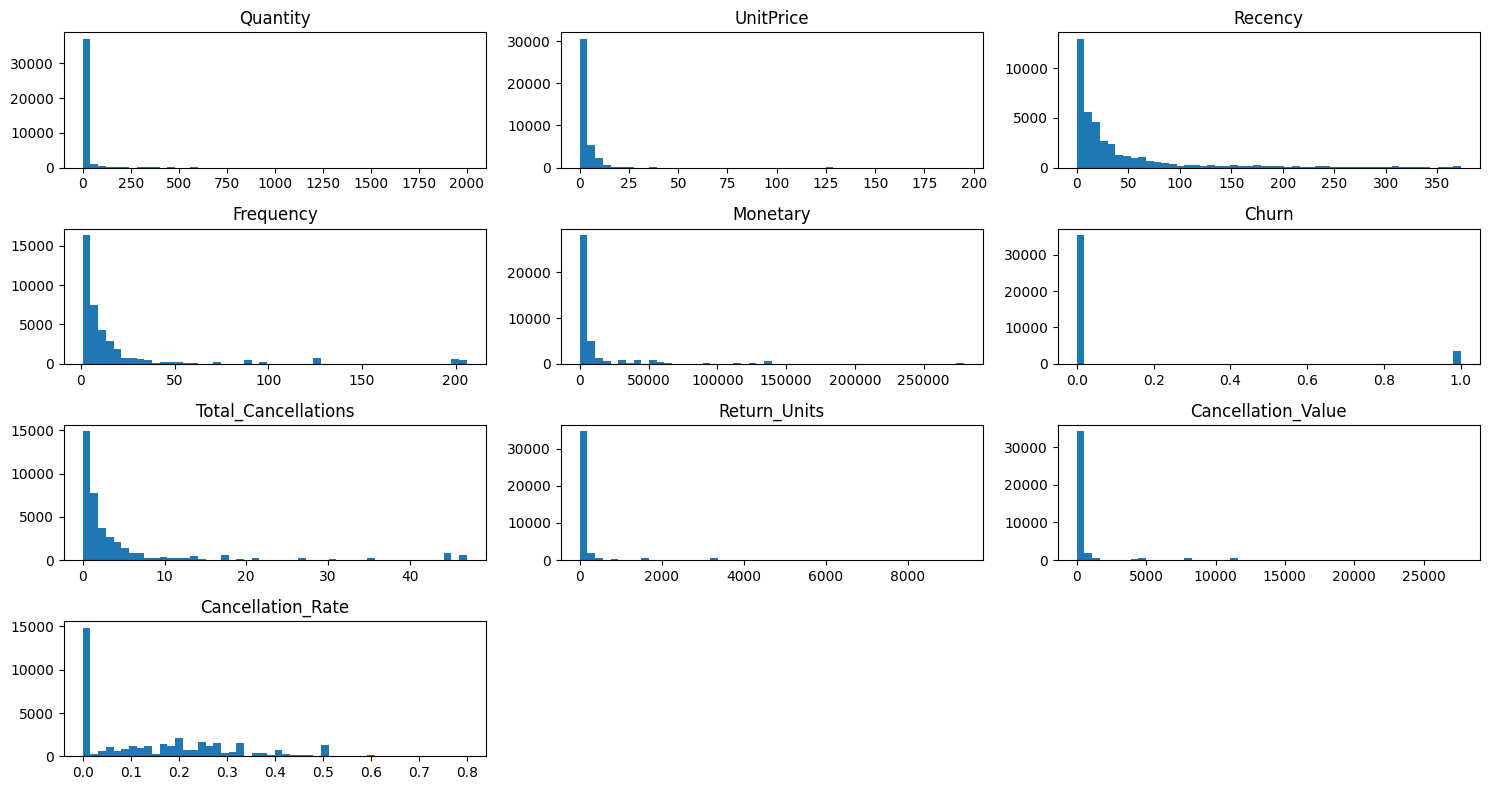

In [73]:
import matplotlib.pyplot as plt

sample_pd[numeric_cols].hist(
    bins=50,
    figsize=(15, 8),
    grid= False
)

plt.tight_layout()
plt.show()

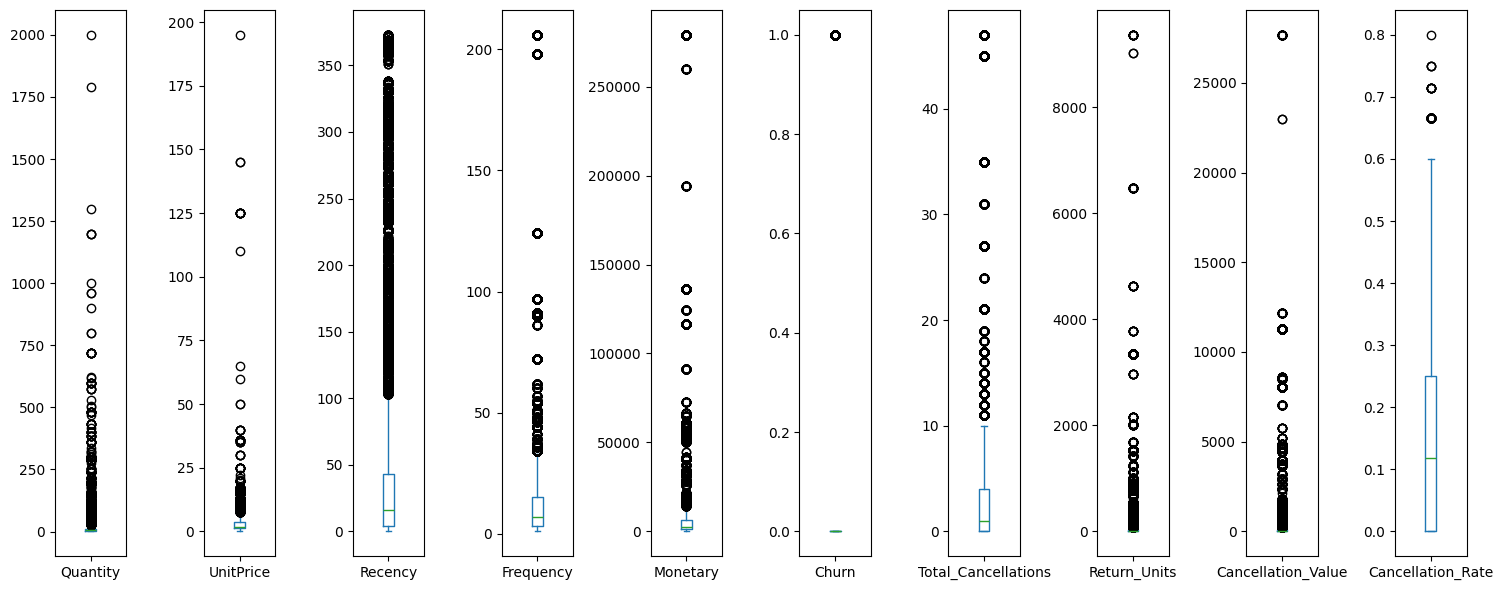

In [74]:
sample_pd[numeric_cols].plot(
    kind="box",
    subplots=True,
    figsize=(15, 6),
    grid= False
)

plt.tight_layout()
plt.show()

In [80]:
# create columns for winsorize
winsor_cols = [
    "Frequency",
    "Monetary",
    "Total_Cancellations",
    "Return_Units",
    "Cancellation_Value"
]

In [81]:
from pyspark.sql import functions as F

def winsorize_spark(
    df,
    columns,
    lower_percentile=0.01,
    upper_percentile=0.99,
    relative_error=0.001
):

    result_df = df
    thresholds = {}

    for col_name in columns:

        # Calculate P1 and P99
        lower, upper = df.approxQuantile(
            col_name,
            [lower_percentile, upper_percentile],
            relative_error
        )

        thresholds[col_name] = {
            "lower": lower,
            "upper": upper
        }

        # Create new winsorized column
        result_df = result_df.withColumn(
            f"{col_name}_winsor",

            F.when(
                F.col(col_name) < lower,
                F.lit(lower)
            )
            .when(
                F.col(col_name) > upper,
                F.lit(upper)
            )
            .otherwise(F.col(col_name))
        )

        print(
            f"{col_name:25s} "
            f"P1 = {lower:.2f} | "
            f"P99 = {upper:.2f}"
        )

    return result_df, thresholds

In [82]:
customer_winsor_df, thresholds = winsorize_spark(
    final_df,
    winsor_cols,
    lower_percentile=0.01,
    upper_percentile=0.99
)

Frequency                 P1 = 1.00 | P99 = 206.00
Monetary                  P1 = 144.06 | P99 = 136161.83
Total_Cancellations       P1 = 0.00 | P99 = 47.00
Return_Units              P1 = 0.00 | P99 = 3335.00
Cancellation_Value        P1 = 0.00 | P99 = 11252.44


In [83]:
plot_cols = []

for col_name in winsor_cols:
    plot_cols.extend([
        col_name,
        f"{col_name}_winsor"
    ])

plot_df = (
    customer_winsor_df
    .select(plot_cols)
    .toPandas()
)

Saved to: /content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Personal Projects/Customer Growth And Retention Analysis/Data Viz/01_winsorization_boxplot_comparison.png


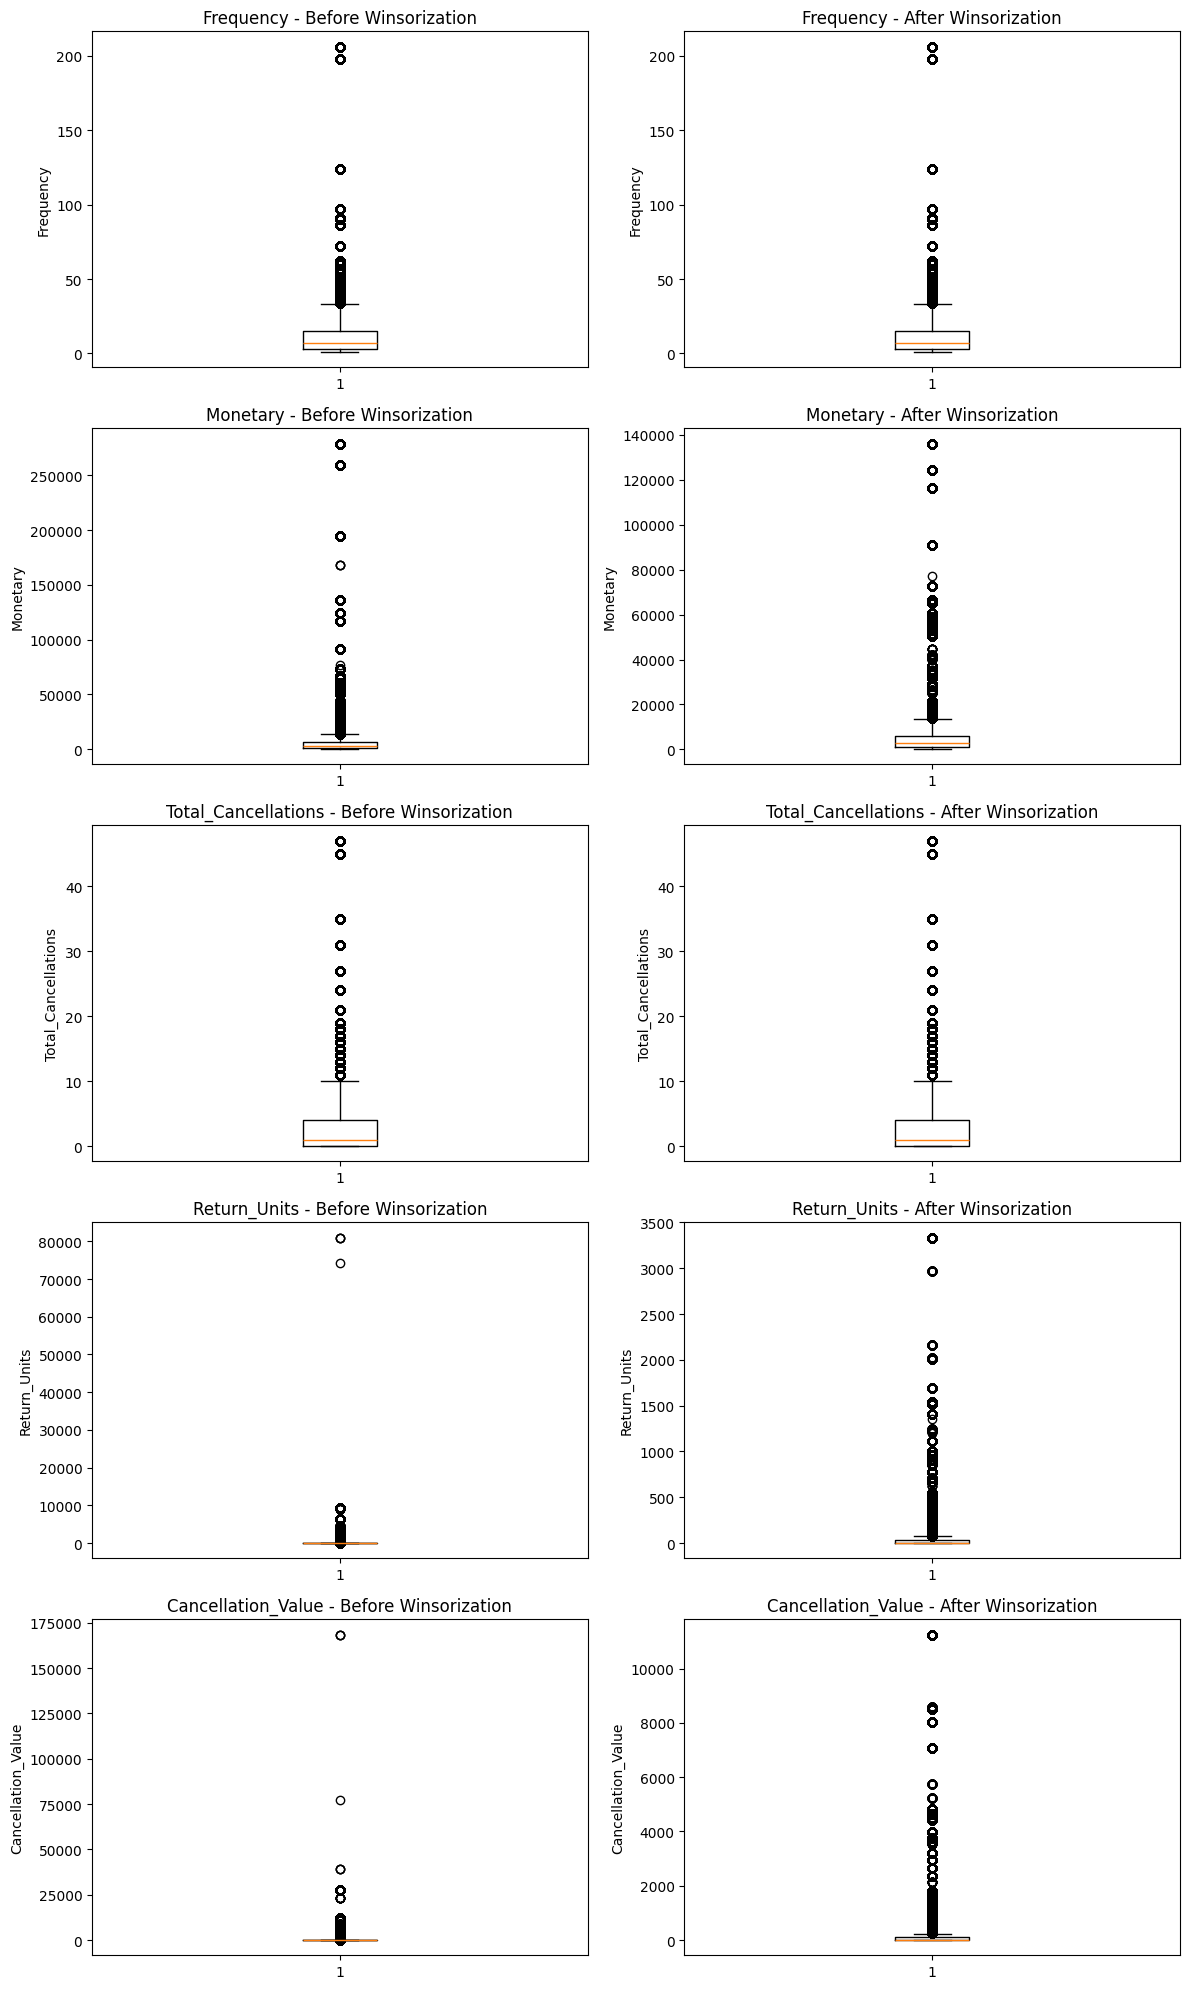

In [94]:
from pathlib import Path
import matplotlib.pyplot as plt

# Save path
SAVE_PATH = Path(
    "/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/"
    "Personal Projects/Customer Growth And Retention Analysis/Data Viz"
)

SAVE_PATH.mkdir(parents=True, exist_ok=True)

# =========================
# CREATE PLOT
# =========================

fig, axes = plt.subplots(
    nrows=len(winsor_cols),
    ncols=2,
    figsize=(12, 4 * len(winsor_cols))
)

for i, col_name in enumerate(winsor_cols):

    # Before
    axes[i, 0].boxplot(
        plot_df[col_name].dropna()
    )
    axes[i, 0].set_title(
        f"{col_name} - Before Winsorization"
    )
    axes[i, 0].set_ylabel(col_name)

    # After
    axes[i, 1].boxplot(
        plot_df[f"{col_name}_winsor"].dropna()
    )
    axes[i, 1].set_title(
        f"{col_name} - After Winsorization"
    )
    axes[i, 1].set_ylabel(col_name)

plt.tight_layout()

# =========================
# SAVE BEFORE plt.show()
# =========================

file_path = SAVE_PATH / "01_winsorization_boxplot_comparison.png"

plt.savefig(
    file_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved to: {file_path}")

plt.show()

### Outlier Treatment Approach

- Extreme values were first inspected to distinguish **data errors from valid purchasing behavior**.
- Valid extreme observations were **retained**, as they may represent high-value or bulk-purchasing customers.
- For modeling, highly skewed numerical features such as **Frequency and Monetary** were winsorized at the **1st and 99th percentiles (P1–P99)**.
- Winsorization caps extreme values rather than removing customers, reducing their influence on the model while preserving customer information.
- Original features were retained alongside winsorized versions for comparison and model validation.

#### 1.2 Growth
- In this section, I will track key metrics reflecting the health of the e-commerce website, to answer the key following questions:
1. Overall key metrics growth YOY, what are growth drivers factors?
2. Seasonal trends QoQ, WoW, any pattern? Those patterns happened in specifics product/place/customers group or accross business (nature of business)


#### Executive Summary


In [95]:
final_df= final_df.withColumn("day_of_week", F.date_format("InvoiceDate", "EEEE")) \
       .withColumn("month", F.month("InvoiceDate")) \
       .withColumn("year", F.year("InvoiceDate")) \
       .withColumn("month_year", F.date_format("InvoiceDate", "yyyy-MM")) \
       .withColumn("quarter_year", F.concat(
           F.year("InvoiceDate"),
           F.lit("-Q"),
           F.quarter("InvoiceDate")
       ))\
       .withColumn("hour", F.hour("InvoiceDate"))

In [96]:
final_df = final_df.withColumn(
    "week_of_month",
    F.ceil(F.dayofmonth("InvoiceDate") / 7)
)

In [97]:
from pyspark.sql import functions as F

final_df = final_df.withColumn(
    "is_christmas_season",
    F.when(
        (F.col("month") == 12) |
        ((F.col("month") == 11) & (F.dayofmonth("InvoiceDate") >= 15)),
        1
    ).otherwise(0)
).withColumn(
    "is_valentine_season",
    F.when(
        (F.col("month") == 2) &
        (F.dayofmonth("InvoiceDate") <= 14),
        1
    ).otherwise(0)
).withColumn(
    "is_mothers_day_season",
    F.when(
        (F.col("year") == 2011) &
        (
            ((F.col("month") == 3) & (F.dayofmonth("InvoiceDate") >= 20)) |
            ((F.col("month") == 4) & (F.dayofmonth("InvoiceDate") <= 3))
        ),
        1
    ).otherwise(0)
).withColumn(
    "is_easter_season",
    F.when(
        (F.col("year") == 2011) &
        (F.col("month") == 4) &
        (F.dayofmonth("InvoiceDate").between(15, 25)),
        1
    ).otherwise(0)
)

In [98]:
final_df.show(10)

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-------------------+------------+------------------+-----------------+-----------+-----+----+----------+------------+----+-------------+-------------------+-------------------+---------------------+----------------+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Customer_Type|Recency|Frequency|Monetary|Churn|Total_Cancellations|Return_Units|Cancellation_Value|Cancellation_Rate|day_of_week|month|year|month_year|quarter_year|hour|week_of_month|is_christmas_season|is_valentine_season|is_mothers_day_season|is_easter_season|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-------------------+------------+------------------+-----------------+-----------+-----+----+----------+--

In [ ]:
def format_km(value):
    """
    Format number into K (thousands) or M (millions)
    """
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return f"{value:.0f}"

### Key Metrics Calculation
- In this section, we'll calculate key metrics to monitor business performance and examine the distribution of each key metrics.
The key metrics include:
1. Total Revenue
2. Total Orders
3. Average Order Value (AOV)
4. Time Gap Between Two Orders
5. Average Basket Size

In [ ]:
final_df = final_df.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("UnitPrice")
)
total_revenue = final_df.agg(F.sum("Revenue")).collect()[0][0]
print(f'Total Revenue: {format_km(total_revenue)}')

Total Revenue: 8.74M


In [ ]:
total_orders = final_df.select("InvoiceNo").distinct().count()
print(f'Total Orders: {format_km(total_orders)}')

Total Orders: 18.40K


In [ ]:
order_df = final_df.groupBy("InvoiceNo").agg(
    F.sum("Revenue").alias("order_revenue")
)

AOV = order_df.agg(F.avg("order_revenue")).collect()[0][0]
print(f'Average Order Value: {format_km(AOV)}')

Average Order Value: 475


In [ ]:
order_df.agg(
    F.expr("percentile_approx(order_revenue, 0.5)").alias("median_AOV"),
    F.expr("percentile_approx(order_revenue, 0.9)").alias("p90_AOV"),
    F.expr("percentile_approx(order_revenue, 0.95)").alias("p95_AOV"),
    F.expr("percentile_approx(order_revenue, 0.99)").alias("p99_AOV")
).show()

+----------+-------+------------------+-------+
|median_AOV|p90_AOV|           p95_AOV|p99_AOV|
+----------+-------+------------------+-------+
|     301.6| 809.92|1209.8799999999999| 3733.0|
+----------+-------+------------------+-------+



In [ ]:
orders = order_df.select("order_revenue").toPandas()

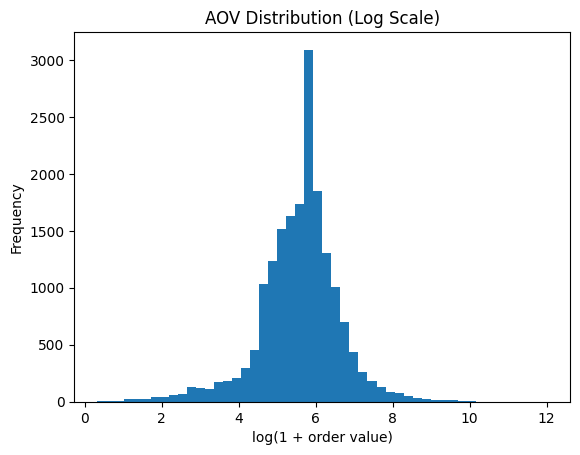

In [ ]:
import numpy as np

plt.figure()
plt.hist(np.log1p(orders["order_revenue"]), bins=50)
plt.title("AOV Distribution (Log Scale)")
plt.xlabel("log(1 + order value)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
basket_df = final_df.groupBy("InvoiceNo").agg(
    F.sum("Quantity").alias("items_per_order")
)

avg_basket_size = basket_df.agg(
    F.avg("items_per_order")
).collect()[0][0]

print(format_km(avg_basket_size))

279


In [ ]:
basket_df.agg(
    F.expr("percentile_approx(items_per_order, 0.5)").alias("median"),
    F.expr("percentile_approx(items_per_order, 0.9)").alias("p90"),
    F.expr("percentile_approx(items_per_order, 0.95)").alias("p95"),
    F.expr("percentile_approx(items_per_order, 0.99)").alias("p99")
).show()

+------+---+---+----+
|median|p90|p95| p99|
+------+---+---+----+
|   156|513|778|2256|
+------+---+---+----+



In [ ]:
basket = basket_df.select("items_per_order").toPandas()

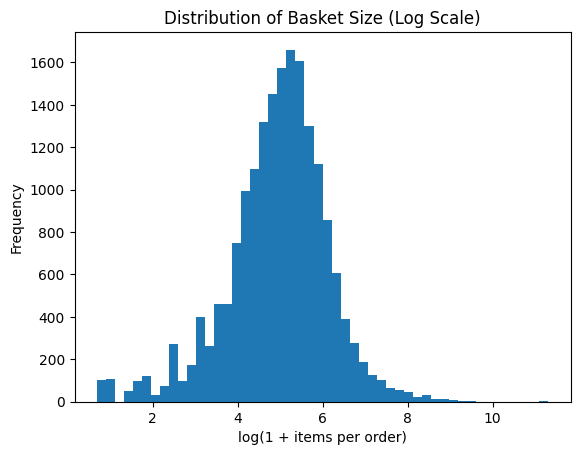

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.hist(np.log1p(basket["items_per_order"]), bins=50)
plt.title("Distribution of Basket Size (Log Scale)")
plt.xlabel("log(1 + items per order)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
customer_freq = final_df.groupBy("CustomerID").agg(
    F.countDistinct("InvoiceNo").alias("frequency"),
)

avg_order_frequency = customer_freq.agg(
    F.avg("frequency")
).collect()[0][0]
print(f'Average Order Frequency: {avg_order_frequency}')

Average Order Frequency: 4.2459621596677435


In [ ]:
freq= customer_freq.select('frequency').toPandas()

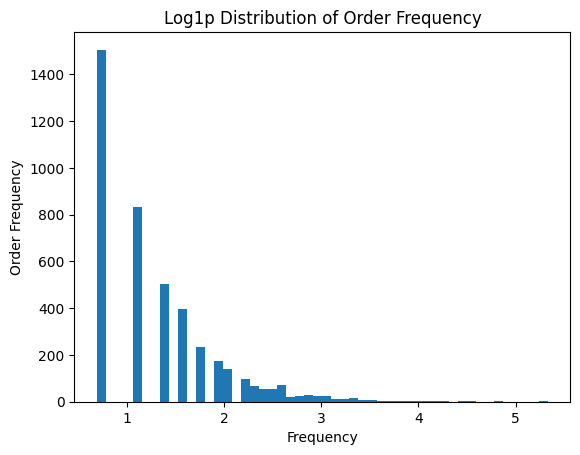

In [ ]:
plt.figure()
plt.hist(np.log1p(freq['frequency']), bins= 50)
plt.title("Log1p Distribution of Order Frequency")
plt.xlabel("Frequency")
plt.ylabel("Order Frequency")
plt.show()

In [ ]:
df_daily = final_df.select("CustomerID", F.to_date("InvoiceDate").alias("PurchaseDate")).distinct()

w = Window.partitionBy("CustomerID").orderBy("PurchaseDate")

df_gap = df_daily.withColumn(
    "prev_date",
    F.lag("PurchaseDate").over(w)
).withColumn(
    "time_gap_days",
    F.datediff("PurchaseDate", F.col("prev_date"))
).filter(F.col("time_gap_days").isNotNull())

In [ ]:
df_gap.agg(

    F.avg("time_gap_days").alias("mean_gap"),

    F.expr("percentile(time_gap_days, 0.5)").alias("median_gap"),

    F.expr("percentile(time_gap_days, 0.9)").alias("p90_gap"),

    F.expr("percentile(time_gap_days, 0.99)").alias("p99_gap")

).show()

+------------------+----------+-------+-------+
|          mean_gap|median_gap|p90_gap|p99_gap|
+------------------+----------+-------+-------+
|45.856529488010366|      28.0|  111.0|  260.0|
+------------------+----------+-------+-------+



In [ ]:
gap = df_gap.select("time_gap_days").toPandas()

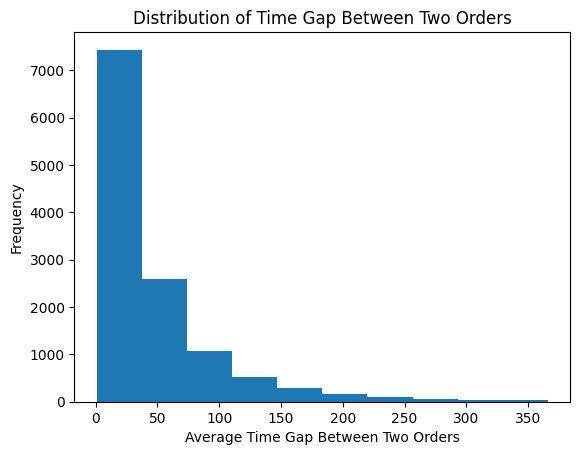

In [ ]:
plt.figure()
plt.hist(gap["time_gap_days"], bins= 10)
plt.title("Distribution of Time Gap Between Two Orders")
plt.xlabel("Average Time Gap Between Two Orders")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#  distribution of unit price
unit_price= final_df.select("UnitPrice").toPandas()

In [ ]:
final_df.agg(

    F.avg("UnitPrice").alias("mean_unitprice"),

    F.expr("percentile(UnitPrice, 0.5)").alias("median_unitprice"),

    F.expr("percentile(UnitPrice, 0.9)").alias("p90_unitprice"),

    F.expr("percentile(UnitPrice, 0.99)").alias("p99_unitprice")

).show()

+------------------+----------------+-------------+-------------+
|    mean_unitprice|median_unitprice|p90_unitprice|p99_unitprice|
+------------------+----------------+-------------+-------------+
|2.8743503258331247|            1.95|         6.25|        12.75|
+------------------+----------------+-------------+-------------+



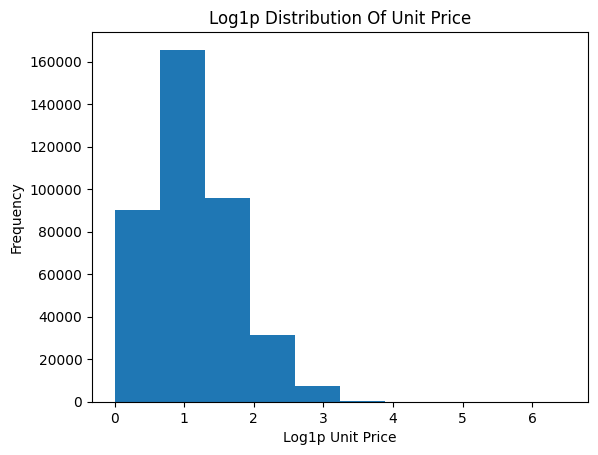

In [ ]:
plt.figure()
plt.hist(np.log1p(unit_price["UnitPrice"]), bins=10)
plt.xlabel("Log1p Unit Price")
plt.ylabel("Frequency")
plt.title("Log1p Distribution Of Unit Price")
plt.show()

#### 1.1. Growth By Time Dimesion

In [ ]:
order_df = final_df.groupBy("InvoiceNo").agg(
    F.sum("Revenue").alias("order_value"),
    F.sum("Quantity").alias("items_per_order"),
     F.first("InvoiceDate").alias("InvoiceDate"),
    F.first("quarter_year").alias("quarter_year"),
    F.first("month").alias('month'),
    F.first("year").alias('year'),
    F.first("week_of_month").alias("week_of_month"),
    F.first("month_year").alias("month_year"),
    F.first("day_of_week").alias("day_of_week"),
    F.first("CustomerID").alias("CustomerID"),
    F.first("Country").alias("Country"),
    F.collect_list("Description").alias("product_list")

)

In [ ]:
order_df.show(5)

+---------+------------------+---------------+-------------------+------------+-----+----+-------------+----------+-----------+----------+--------------+--------------------+
|InvoiceNo|       order_value|items_per_order|        InvoiceDate|quarter_year|month|year|week_of_month|month_year|day_of_week|CustomerID|       Country|        product_list|
+---------+------------------+---------------+-------------------+------------+-----+----+-------------+----------+-----------+----------+--------------+--------------------+
|   536366|22.200000000000003|             12|2010-12-01 08:28:00|     2010-Q4|   12|2010|            1|   2010-12|  Wednesday|     17850|United Kingdom|[HAND WARMER UNIO...|
|   536367|            278.73|             83|2010-12-01 08:34:00|     2010-Q4|   12|2010|            1|   2010-12|  Wednesday|     13047|United Kingdom|[BOX OF VINTAGE A...|
|   536371|             204.0|             80|2010-12-01 09:00:00|     2010-Q4|   12|2010|            1|   2010-12|  Wednesda

In [ ]:
kpi_by_quarter = order_df.groupBy("quarter_year").agg(

    F.sum("order_value").alias("Total_Revenue"),
    F.countDistinct("InvoiceNo").alias("Total_Orders"),
    F.countDistinct("CustomerID").alias("Total_Customers"),

    (F.sum("order_value") / F.countDistinct("InvoiceNo")).alias("AOV"),

    (F.countDistinct("InvoiceNo") / F.countDistinct("CustomerID")).alias("Order_Frequency"),

    F.avg("items_per_order").alias("Avg_Items_Per_Order")
)

In [ ]:
kpi= kpi_by_quarter.toPandas().sort_values("quarter_year")

In [ ]:
kpi.to_csv('/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Personal Projects/Customer Growth And Retention Analysis/data_files/kpi_by_quarter.csv')

In [ ]:
# filter orders in 2010 and 2011
order_2010= order_df.filter(F.col("year")==2010)
order_2011= order_df.filter(F.col("year")==2011)

In [ ]:
order_11= order_2011.groupBy("month").agg(
    F.count("InvoiceNo").alias("Total_Orders")
).orderBy("month")

In [ ]:
order_11= order_11.toPandas()

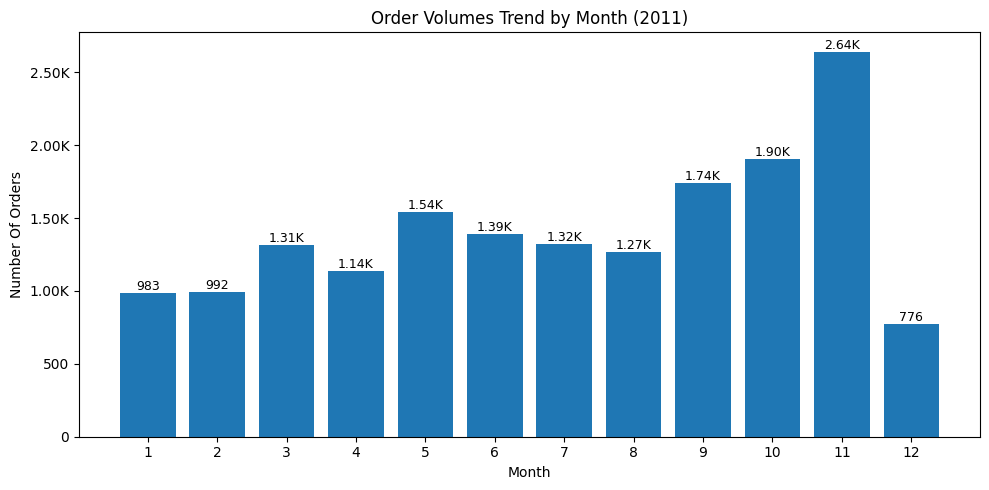

In [ ]:
# plot
plt.figure(figsize=(10,5))

plt.bar(order_11["month"], order_11["Total_Orders"])

plt.grid(False)
for x, y in zip(order_11["month"], order_11["Total_Orders"]):
    plt.text(x, y, format_km(y), ha="center", va="bottom", fontsize=9)

plt.xticks(range(1,13))

plt.title("Order Volumes Trend by Month (2011)")
plt.xlabel("Month")
plt.ylabel("Number Of Orders")
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: format_km(x))
)

plt.tight_layout()
plt.show()

In [ ]:
aov_quarter= order_df.groupby("quarter_year").agg(
    F.sum("order_value").alias("total_order_value"),
    F.count("InvoiceNo").alias("total_orders")
).withColumn("AOV",F.col("total_order_value")/ F.col("total_orders"))

In [ ]:
aov_quarter= aov_quarter.toPandas()

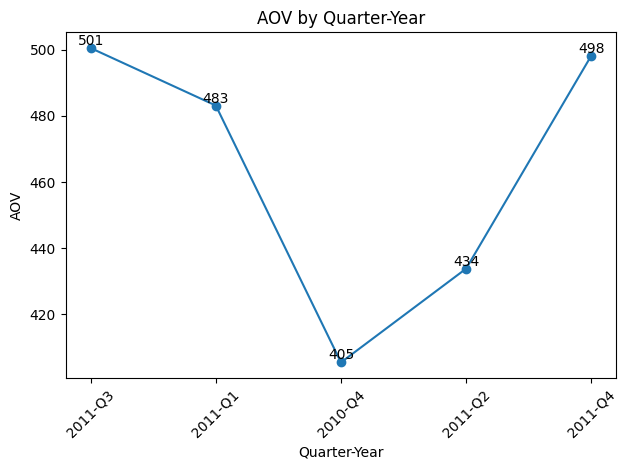

In [ ]:
import matplotlib.ticker as mtick

plt.figure()

plt.plot(aov_quarter["quarter_year"], aov_quarter["AOV"], marker='o')

plt.xticks(rotation=45)
plt.xlabel("Quarter-Year")
plt.ylabel("AOV")
plt.title("AOV by Quarter-Year")
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: format_km(x))
)

for x, y in zip(aov_quarter["quarter_year"], aov_quarter["AOV"]):
    plt.text(x, y, format_km(y), ha='center', va='bottom')

plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
aov_2011= order_2011.groupby("month").agg(
    F.sum("order_value").alias("total_order_value"),
    F.count("InvoiceNo").alias("total_orders")
).withColumn("AOV",F.col("total_order_value")/ F.col("total_orders"))

In [ ]:
aov_2011= aov_2011.toPandas().sort_values("month")

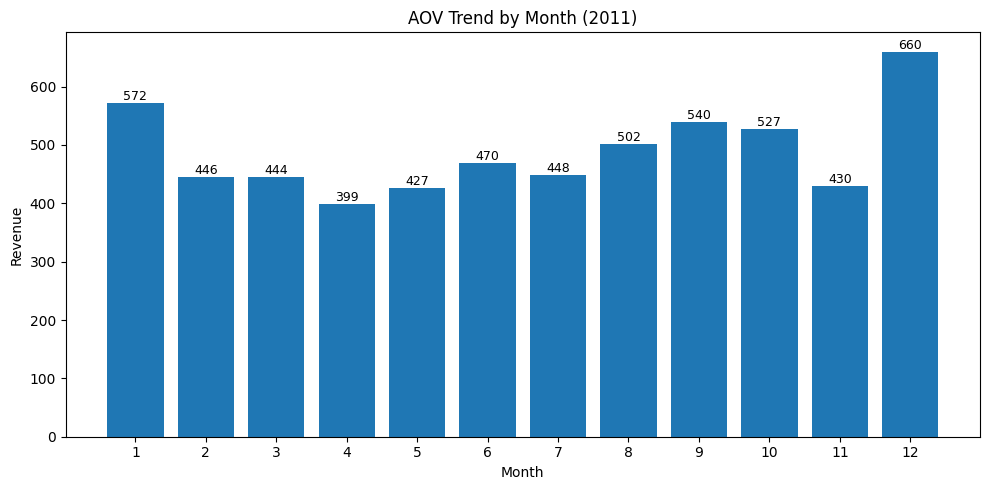

In [ ]:
# plot
plt.figure(figsize=(10,5))

plt.bar(aov_2011["month"], aov_2011["AOV"])

plt.grid(False)
for x, y in zip(aov_2011["month"], aov_2011["AOV"]):
    plt.text(x, y, format_km(y), ha="center", va="bottom", fontsize=9)

plt.xticks(range(1,13))

plt.title("AOV Trend by Month (2011)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: format_km(x))
)

plt.tight_layout()
plt.show()

In [ ]:
sales_2011= order_2011.groupby("month").agg(
    F.sum("order_value").alias("Revenue")
)

In [ ]:
sales_2011= sales_2011.toPandas().sort_values("month")

In [ ]:
sales_2011.to_csv('/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Personal Projects/Customer Growth And Retention Analysis/data_files/sales_trend_2011_by_month.csv')

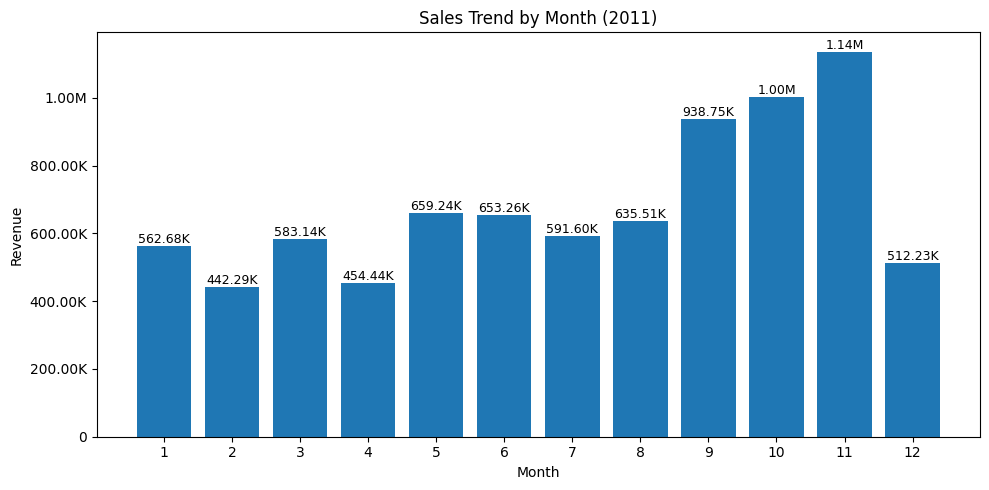

In [ ]:
# plot
plt.figure(figsize=(10,5))

plt.bar(sales_2011["month"], sales_2011["Revenue"])

plt.grid(False)
for x, y in zip(sales_2011["month"], sales_2011["Revenue"]):
    plt.text(x, y, format_km(y), ha="center", va="bottom", fontsize=9)

plt.xticks(range(1,13))

plt.title("Sales Trend by Month (2011)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: format_km(x))
)

plt.tight_layout()
plt.show()

In [ ]:
quarter_df= order_df.groupby(
    "quarter_year",
    "week_of_month"
).agg(
    F.sum("order_value").alias("Revenue")
).orderBy("quarter_year","week_of_month")

In [ ]:
quarter_df = quarter_df.toPandas()

In [ ]:
quarter_df = quarter_df.pivot(
    index="week_of_month",
    columns="quarter_year",
    values="Revenue"
).sort_index()

In [ ]:
quarter_df.to_csv('/content/drive/MyDrive/Dinh Thi Thanh Hang- Portfolio/Personal Projects/Customer Growth And Retention Analysis/data_files/quarter-year sales by week of month.csv')

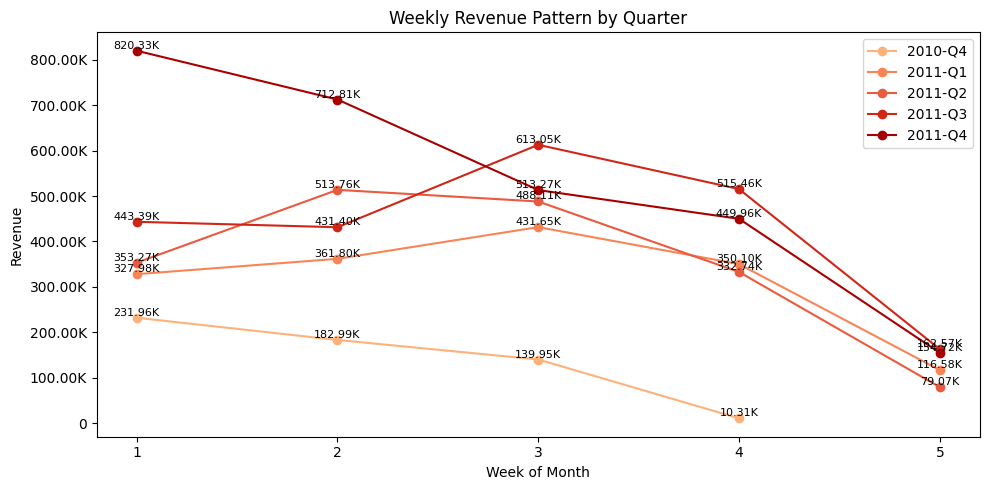

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plt.figure(figsize=(10,5))

# tạo color map đỏ
colors = plt.cm.OrRd(np.linspace(0.4, 0.9, len(quarter_df.columns)))

for i, col in enumerate(quarter_df.columns):

    x = quarter_df.index
    y = quarter_df[col]

    plt.plot(x, y, marker="o", label=col, color=colors[i])

    # add label từng điểm
    for xi, yi in zip(x, y):
        if not np.isnan(yi):
            plt.text(xi, yi, format_km(yi),
                     ha="center", va="bottom", fontsize=8)

plt.title("Weekly Revenue Pattern by Quarter")
plt.xlabel("Week of Month")
plt.ylabel("Revenue")
plt.xticks([1,2,3,4,5])
plt.legend()
plt.grid(False)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: format_km(x))
)

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# =========================
# 1. ORDERS BY WEEK OF MONTH
# =========================

week_2011 = (
    order_df
    .filter(F.col("year") == 2011)
    .groupBy("week_of_month")
    .agg(
        F.countDistinct("InvoiceNo").alias("orders"),
        F.round(F.sum("order_value"), 2).alias("revenue"),
        F.sum("items_per_order").alias("items")
    )
)

week_2011 = (
    week_2011
    .withColumn(
        "order_share_pct",
        F.round(
            F.col("orders") /
            F.sum("orders").over(Window.partitionBy()) * 100,
            2
        )
    )
    .withColumn(
        "revenue_share_pct",
        F.round(
            F.col("revenue") /
            F.sum("revenue").over(Window.partitionBy()) * 100,
            2
        )
    )
    .orderBy("week_of_month")
)

week_2011.show()

+-------------+------+----------+-------+---------------+-----------------+
|week_of_month|orders|   revenue|  items|order_share_pct|revenue_share_pct|
+-------------+------+----------+-------+---------------+-----------------+
|            1|  4168|1944968.82|1159663|          24.51|             23.8|
|            2|  3962| 2019769.8|1159498|          23.29|            24.72|
|            3|  3886|2046083.06|1213786|          22.85|            25.04|
|            4|  3838|1648257.76|1000619|          22.57|            20.17|
|            5|  1154| 512948.64| 297598|           6.79|             6.28|
+-------------+------+----------+-------+---------------+-----------------+



In [ ]:
# =========================
# 2. ORDERS BY DAY OF WEEK
# =========================

day_2011 = (
    order_df
    .filter(F.col("year") == 2011)
    .groupBy("day_of_week")
    .agg(
        F.countDistinct("InvoiceNo").alias("orders"),
        F.round(F.sum("order_value"), 2).alias("revenue"),
        F.sum("items_per_order").alias("items")
    )
)

day_2011 = (
    day_2011
    .withColumn(
        "order_share_pct",
        F.round(
            F.col("orders") /
            F.sum("orders").over(Window.partitionBy()) * 100,
            2
        )
    )
    .withColumn(
        "revenue_share_pct",
        F.round(
            F.col("revenue") /
            F.sum("revenue").over(Window.partitionBy()) * 100,
            2
        )
    )
    .withColumn(
        "day_order",
        F.when(F.col("day_of_week") == "Monday", 1)
         .when(F.col("day_of_week") == "Tuesday", 2)
         .when(F.col("day_of_week") == "Wednesday", 3)
         .when(F.col("day_of_week") == "Thursday", 4)
         .when(F.col("day_of_week") == "Friday", 5)
         .when(F.col("day_of_week") == "Saturday", 6)
         .when(F.col("day_of_week") == "Sunday", 7)
    )
    .orderBy("day_order")
)

day_2011.select(
    "day_of_week",
    "orders",
    "revenue",
    "items",
    "order_share_pct",
    "revenue_share_pct"
).show()

+-----------+------+----------+-------+---------------+-----------------+
|day_of_week|orders|   revenue|  items|order_share_pct|revenue_share_pct|
+-----------+------+----------+-------+---------------+-----------------+
|     Monday|  2622|1248887.43| 720129|          15.42|            15.28|
|    Tuesday|  2979|1574173.13| 954788|          17.52|            19.26|
|  Wednesday|  3121|1439615.54| 890855|          18.35|            17.62|
|   Thursday|  3640|1800452.39|1066404|           21.4|            22.03|
|     Friday|  2626|1384339.41| 768833|          15.44|            16.94|
|     Sunday|  2020| 724560.18| 430155|          11.88|             8.87|
+-----------+------+----------+-------+---------------+-----------------+



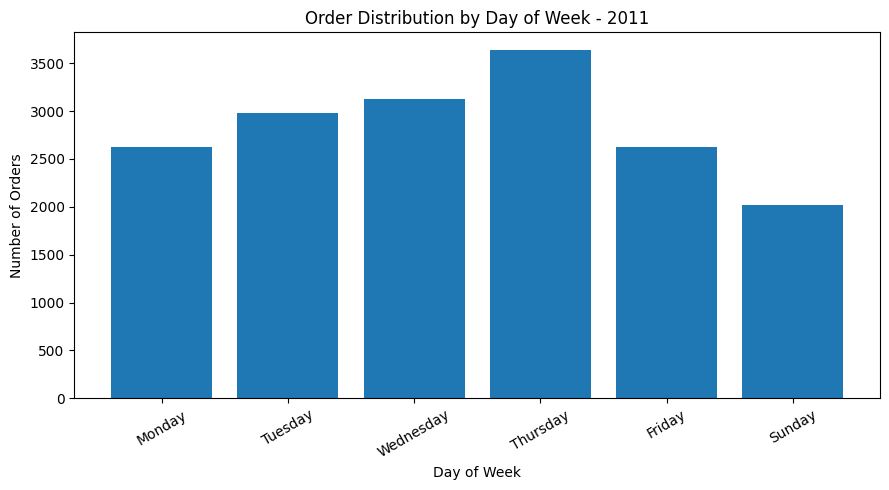

In [ ]:
import matplotlib.pyplot as plt

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_pd = day_2011.select(
    "day_of_week", "orders"
).toPandas()

day_pd["day_of_week"] = pd.Categorical(
    day_pd["day_of_week"],
    categories=day_order,
    ordered=True
)

day_pd = day_pd.sort_values("day_of_week")

plt.figure(figsize=(9, 5))
plt.bar(day_pd["day_of_week"], day_pd["orders"])

plt.title("Order Distribution by Day of Week - 2011")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 3. WEEK OF MONTH × DAY
# =========================

week_day_2011 = (
    order_df
    .filter(F.col("year") == 2011)
    .groupBy(
        "week_of_month",
        "day_of_week"
    )
    .agg(
        F.countDistinct("InvoiceNo").alias("orders"),
        F.round(F.sum("order_value"), 2).alias("revenue")
    )
    .orderBy(
        "week_of_month",
        F.desc("orders")
    )
)

week_day_2011.show(50, truncate=False)

+-------------+-----------+------+---------+
|week_of_month|day_of_week|orders|revenue  |
+-------------+-----------+------+---------+
|1            |Thursday   |880   |447899.49|
|1            |Friday     |764   |336060.77|
|1            |Tuesday    |743   |325358.56|
|1            |Wednesday  |733   |370736.57|
|1            |Monday     |607   |309068.79|
|1            |Sunday     |441   |155844.64|
|2            |Thursday   |890   |445843.0 |
|2            |Wednesday  |692   |282359.86|
|2            |Friday     |644   |490902.15|
|2            |Monday     |637   |290051.76|
|2            |Tuesday    |637   |357541.65|
|2            |Sunday     |462   |153071.38|
|3            |Thursday   |821   |422924.81|
|3            |Wednesday  |697   |359202.84|
|3            |Tuesday    |655   |472369.19|
|3            |Monday     |649   |343228.31|
|3            |Friday     |576   |269989.72|
|3            |Sunday     |488   |178368.19|
|4            |Thursday   |822   |372371.47|
|4        

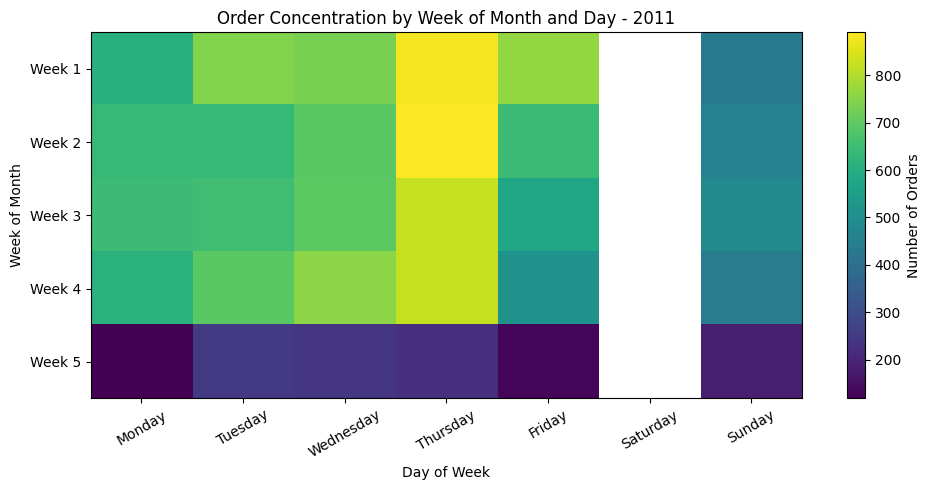

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

heatmap_pd = week_day_2011.toPandas()

pivot = heatmap_pd.pivot(
    index="week_of_month",
    columns="day_of_week",
    values="orders"
).fillna(0)

pivot = pivot.reindex(columns=day_order)

plt.figure(figsize=(10, 5))

plt.imshow(
    pivot.values,
    aspect="auto"
)

plt.colorbar(label="Number of Orders")

plt.xticks(
    range(len(day_order)),
    day_order,
    rotation=30
)

plt.yticks(
    range(len(pivot.index)),
    [f"Week {x}" for x in pivot.index]
)

plt.xlabel("Day of Week")
plt.ylabel("Week of Month")
plt.title("Order Concentration by Week of Month and Day - 2011")

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql import functions as F

monthly_day_revenue = (
    order_df
    .filter(F.col("year") == 2011)
    .groupBy(
        "month",
        "month_year",
        "day_of_week"
    )
    .agg(
        F.countDistinct("InvoiceNo").alias("orders"),
        F.round(F.sum("order_value"), 2).alias("revenue"),
        F.round(F.avg("order_value"), 2).alias("aov")
    )
    .orderBy(
        "month",
        "day_of_week"
    )
)

monthly_day_revenue.show(100, truncate=False)

+-----+----------+-----------+------+---------+-------+
|month|month_year|day_of_week|orders|revenue  |aov    |
+-----+----------+-----------+------+---------+-------+
|1    |2011-01   |Friday     |155   |103682.7 |668.92 |
|1    |2011-01   |Monday     |180   |67158.53 |373.1  |
|1    |2011-01   |Sunday     |124   |39115.28 |315.45 |
|1    |2011-01   |Thursday   |171   |86088.62 |503.44 |
|1    |2011-01   |Tuesday    |177   |182587.13|1031.57|
|1    |2011-01   |Wednesday  |176   |84050.65 |477.56 |
|2    |2011-02   |Friday     |162   |68718.79 |424.19 |
|2    |2011-02   |Monday     |157   |92972.33 |592.18 |
|2    |2011-02   |Sunday     |90    |27884.26 |309.83 |
|2    |2011-02   |Thursday   |191   |74729.84 |391.26 |
|2    |2011-02   |Tuesday    |199   |106914.2 |537.26 |
|2    |2011-02   |Wednesday  |193   |71074.17 |368.26 |
|3    |2011-03   |Friday     |194   |84051.81 |433.26 |
|3    |2011-03   |Monday     |210   |81139.6  |386.38 |
|3    |2011-03   |Sunday     |130   |42783.62 |3

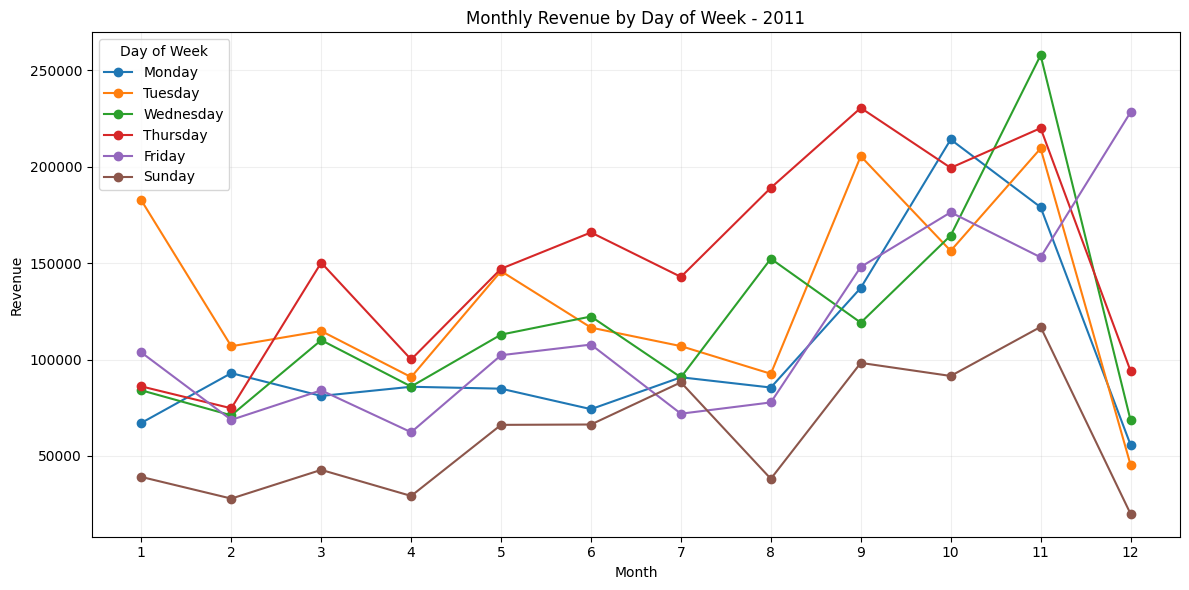

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

monthly_day_pd = monthly_day_revenue.toPandas()

pivot_revenue = (
    monthly_day_pd
    .pivot(
        index="month",
        columns="day_of_week",
        values="revenue"
    )
    .reindex(columns=day_order)
)

plt.figure(figsize=(12, 6))

for day in pivot_revenue.columns:
    if pivot_revenue[day].notna().any():
        plt.plot(
            pivot_revenue.index,
            pivot_revenue[day],
            marker="o",
            label=day
        )

plt.title("Monthly Revenue by Day of Week - 2011")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(range(1, 13))
plt.legend(title="Day of Week")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.window import Window

w_month = Window.partitionBy("month_year")

monthly_day_revenue_share = (
    monthly_day_revenue
    .withColumn(
        "revenue_share_pct",
        F.round(
            F.col("revenue") /
            F.sum("revenue").over(w_month) * 100,
            2
        )
    )
)

monthly_day_revenue_share.show(100, truncate=False)

+-----+----------+-----------+------+---------+-------+-----------------+
|month|month_year|day_of_week|orders|revenue  |aov    |revenue_share_pct|
+-----+----------+-----------+------+---------+-------+-----------------+
|1    |2011-01   |Friday     |155   |103682.7 |668.92 |18.43            |
|1    |2011-01   |Monday     |180   |67158.53 |373.1  |11.94            |
|1    |2011-01   |Sunday     |124   |39115.28 |315.45 |6.95             |
|1    |2011-01   |Thursday   |171   |86088.62 |503.44 |15.3             |
|1    |2011-01   |Tuesday    |177   |182587.13|1031.57|32.45            |
|1    |2011-01   |Wednesday  |176   |84050.65 |477.56 |14.94            |
|2    |2011-02   |Friday     |162   |68718.79 |424.19 |15.54            |
|2    |2011-02   |Monday     |157   |92972.33 |592.18 |21.02            |
|2    |2011-02   |Sunday     |90    |27884.26 |309.83 |6.3              |
|2    |2011-02   |Thursday   |191   |74729.84 |391.26 |16.9             |
|2    |2011-02   |Tuesday    |199   |1

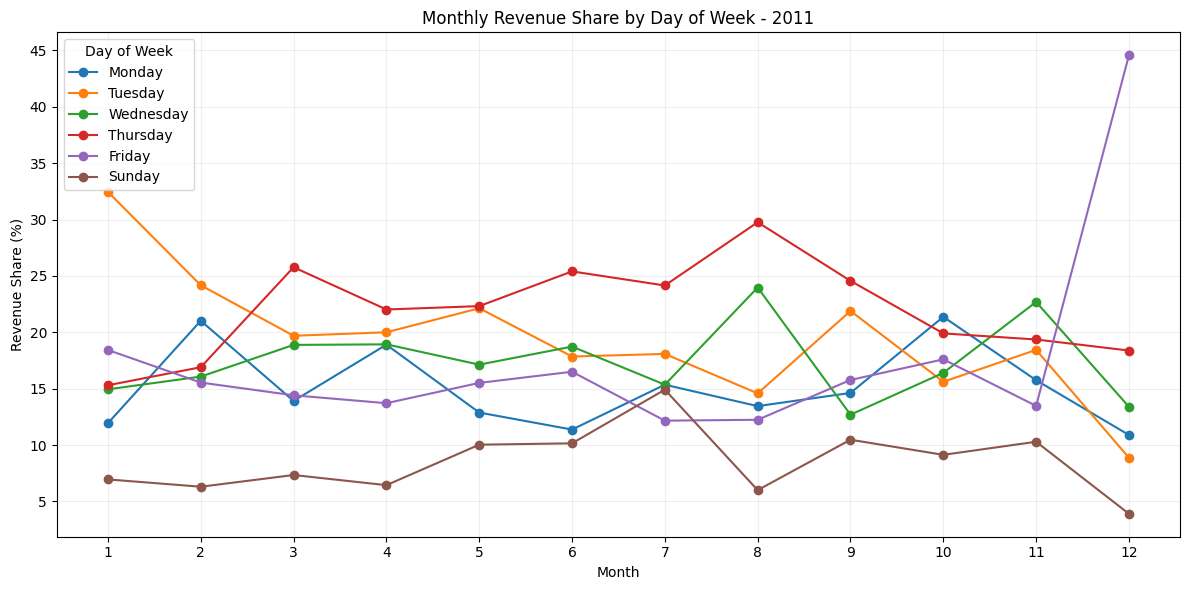

In [ ]:
share_pd = monthly_day_revenue_share.toPandas()

pivot_share = (
    share_pd
    .pivot(
        index="month",
        columns="day_of_week",
        values="revenue_share_pct"
    )
    .reindex(columns=day_order)
)

plt.figure(figsize=(12, 6))

for day in pivot_share.columns:
    if pivot_share[day].notna().any():
        plt.plot(
            pivot_share.index,
            pivot_share[day],
            marker="o",
            label=day
        )

plt.title("Monthly Revenue Share by Day of Week - 2011")
plt.xlabel("Month")
plt.ylabel("Revenue Share (%)")
plt.xticks(range(1, 13))
plt.legend(title="Day of Week")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
final_df.show(5)

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-----------+-----+----+----------+------------+----+-------------+-------------------+-------------------+---------------------+----------------+-------+-------------+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Customer_Type|Recency|Frequency|Monetary|Churn|day_of_week|month|year|month_year|quarter_year|hour|week_of_month|is_christmas_season|is_valentine_season|is_mothers_day_season|is_easter_season|Revenue|price_segment|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-----------+-----+----+----------+------------+----+-------------+-------------------+-------------------+---------------------+----------------+-------+-------------+
|     12346|   541431|    23166|ME

### Summary Of Insights: **2011 growth was primarily customer-led: the business scaled by serving more customers and generating more orders, rather than materially increasing spend per order.**
- Revenue grew consistently throughout 2011, but the underlying growth drivers shifted across quarters. Overall, customer-base expansion was the most sustainable driver, while purchasing frequency and basket value provided secondary contributions.

- Q2 growth (+11.3%) was volume-driven. Customers increased 12.1% and order frequency 10.6%, resulting in 23.9% more orders. However, AOV fell 10.2%, partially offsetting the volume gain.
- Q3 growth (+22.6%) shifted toward basket value. Customer growth remained positive at 8.4%, while AOV jumped 15.4%, accompanied by a 19.9% increase in items per order. This suggests customers were placing larger baskets rather than purchasing more frequently.
- Q4 growth (+22.4%) returned to customer acquisition and order volume. Customers increased 18.7% and orders 23.0%, while AOV remained nearly flat (−0.5%). Therefore, Q4 growth was primarily driven by more customers rather than higher spending per order.
- Across Q1 → Q4, revenue increased roughly 67%, alongside +44% customers and +12% order frequency, while AOV increased only ~3%. This indicates that customer-base expansion was the dominant long-term revenue driver, rather than price/basket-size expansion.

### Key Takeaways: **Align inventory and operations with the observed shift in purchasing timing. Maintain Thursday as a core fulfillment day while preparing inventory and operational capacity earlier in the week during peak-season months, particularly from September onward.**

- Thursday remained the core purchasing day throughout 2011; however, from August onward, customer spending gradually shifted toward the beginning and middle of the working week.

- Before August, Thursday consistently accounted for the largest share of revenue, often contributing around 20–30% of monthly sales.
- From September onward, Monday–Wednesday became increasingly important, with revenue peaks appearing on Tuesday in September, Monday in October, and Wednesday in November.
- Despite this shift, Thursday remained a stable and significant revenue contributor, indicating that the business retained its traditional mid-week purchasing pattern while gaining additional demand earlier in the week.
The shift coincides with the Q4 revenue acceleration and may partly reflect seasonal purchasing behavior ahead of the Christmas period. However, seasonality should be treated as a hypothesis unless confirmed through product mix/order characteristics.

**Use promotions to reshape rather than subsidize existing demand: test targeted incentives during weaker periods (e.g. Friday/Sunday or weaker weeks) instead of discounting Monday–Thursday, while using early-week recommendations, bundles, or cross-sell campaigns to increase basket value when purchase intent is already high.**

#### Price:
- Price segmentation based on quantile
- Are our customers shifting towards more high-end lines of products?


In [ ]:
from pyspark.sql import functions as F
quantiles= final_df.approxQuantile("UnitPrice",[0.25,0.5,0.75],0.01)
q1, q2, q3 = quantiles

print(q1, q2, q3)

1.25 1.95 3.75


In [ ]:
# unit price segmentation
final_df= final_df.withColumn(
    "price_segment",
    F.when(F.col("UnitPrice")<=q1,"Low")
      .when(F.col("UnitPrice")<=q2,"Medium")
      .when(F.col("UnitPrice")<=q3,"High")
      .otherwise("High-end")
)

In [ ]:
quarter_price= final_df.groupby("quarter_year","price_segment").agg(
    F.countDistinct("InvoiceNo").alias("Total_Orders"),
    F.sum("Revenue").alias("Total_Revenue"),
    F.count("CustomerID").alias("Total_Customer")
)

In [ ]:
quarter_price= quarter_price.toPandas().sort_values('quarter_year')

In [ ]:
quarter_price= quarter_price.pivot(
    index='quarter_year',
    columns='price_segment',
    values='Total_Orders'
)

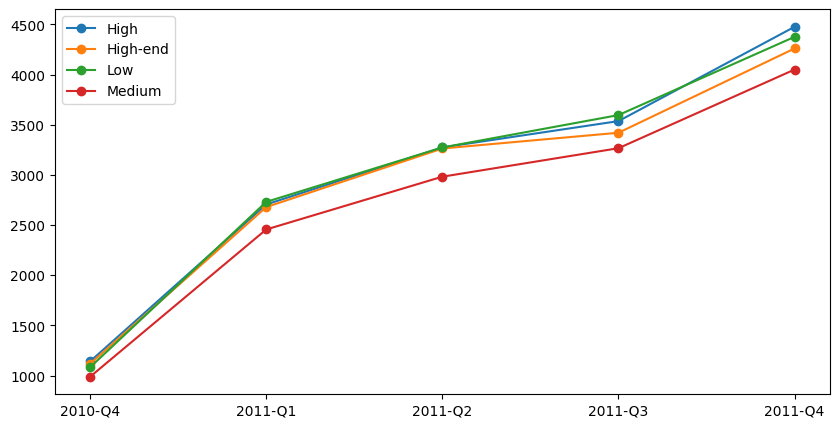

In [ ]:
plt.figure(figsize=(10,5))
for col in quarter_price.columns:
  plt.plot(quarter_price.index, quarter_price[col],marker='o',label=col)
plt.grid(False)
plt.legend()
plt.show()

In [ ]:
# unit price by month of 2011
month_price= final_df.groupby("month_year","price_segment").agg(
    F.countDistinct("InvoiceNo").alias("Total_Orders"),
    F.sum("Revenue").alias("Total_Revenue"),
    F.count("CustomerID").alias("Total_Customer")
)

In [ ]:
month_price= month_price.toPandas().sort_values('month_year')

In [ ]:
month_price= month_price.pivot(
    index='month_year',
    columns='price_segment',
    values='Total_Orders'
)

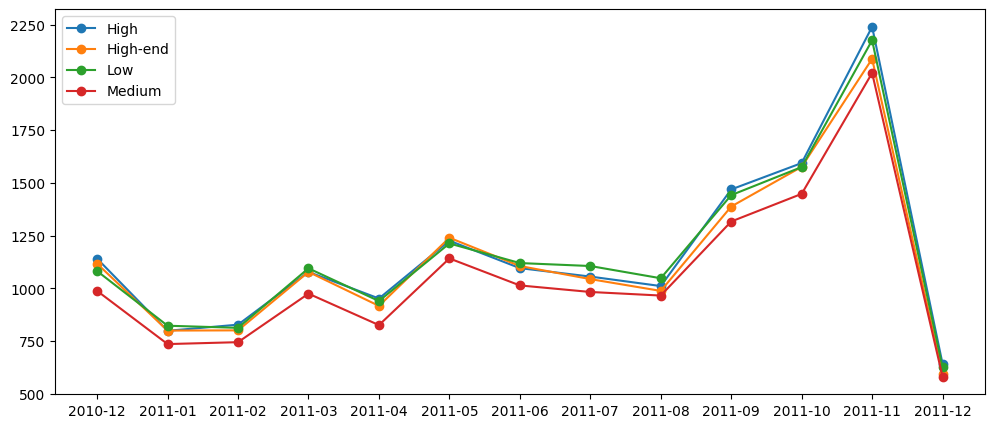

In [ ]:
plt.figure(figsize=(12,5))
for col in month_price.columns:
  plt.plot(month_price.index, month_price[col],marker='o',label=col)
plt.grid(False)
plt.legend()
plt.show()

#### Key Takeaways:
- The low-end products which was always our dominat segment of products, has declined in term of total sales, with the rise of mid-end products in the 11/2011 and 12/2011 together with the peak of sales.
- 11/2011 shows no clear increase in terms of AOV or order items per order, the seasonal sale spike in this month, is highly comes from a newly acquired customers segment, with spending behavior shifting towards mid-end products.

### Executive Summary Of Growth

#### Product
**Big questions:** Which SKUS business should scale up/scale down?

- Revenue vs Sales (Item sold) contribution by Category
- What products are most canceled?
- High-grow products especially in the peak in November 2011?
- Are there gateway products that lead to retention?
- Do retained users explore more categories?
- Are churned users concentrated in few products?
- What products are commonly first purchases?
- What products drive repeat purchases?
- What product combinations drive repeat purchasing?

In [ ]:
from pyspark.sql.functions import col

In [ ]:
total_revenue= final_df.agg(F.sum("Revenue")).collect()[0][0]

In [ ]:
top_products = (
    final_df
    .groupBy("StockCode", "Description")
    .agg(F.sum("Revenue").alias("product_revenue"))
    .orderBy(F.col("product_revenue").desc())
).withColumn(
    'revenue_pct',(F.col("product_revenue")/total_revenue) * 100
)

In [ ]:
top_products = top_products.limit(5).toPandas()

In [ ]:
top_products.head()

,StockCode,Description,product_revenue,revenue_pct
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1.928181
1,22423,REGENCY CAKESTAND 3 TIER,142264.75,1.628260
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,1.149016
3,85099B,JUMBO BAG RED RETROSPOT,85040.54,0.973313
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,0.931837


In [ ]:
final_df.show(5)

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------+---------+--------+-----+-----------+-----+----+----------+------------+----+-------------+------------------+-------------+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Recency|Frequency|Monetary|Churn|day_of_week|month|year|month_year|quarter_year|hour|week_of_month|           Revenue|price_segment|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------+---------+--------+-----+-----------+-----+----+----------+------------+----+-------------+------------------+-------------+
|     12838|   536415|    22951|60 CAKE CASES DOL...|       2|2010-12-01 11:57:00|     0.55|United Kingdom|     33|        2|  671.95|    0|  Wednesday|   12|2010|   2010-12|     2010-Q4|  11|            1|               1.1|          Low|
|     15012|   536522|    22569|FELTCRAF

In [ ]:
from pyspark.sql.functions import countDistinct

category_diversity = (
    final_df
    .groupBy("CustomerID", "Churn")
    .agg(
        countDistinct("Description").alias("num_products")
    )
)

category_diversity.groupBy("Churn").avg("num_products").show()

+-----+------------------+
|Churn| avg(num_products)|
+-----+------------------+
|    1|26.352753391859537|
|    0| 76.17559234014931|
+-----+------------------+



In [ ]:
from pyspark.sql import functions as F

customer_diversity = (
    final_df
    .groupBy("CustomerID")
    .agg(
        F.countDistinct("StockCode").alias("unique_products"),
        F.first("Churn").alias("Churn")
    )
)

customer_diversity.groupBy("unique_products")\
    .agg(
        F.count("*").alias("customers"),
        F.avg("Churn").alias("churn_rate")
    )\
    .orderBy("unique_products")\
    .show(100, False)

+---------------+---------+--------------------+
|unique_products|customers|churn_rate          |
+---------------+---------+--------------------+
|1              |94       |0.7127659574468085  |
|2              |51       |0.45098039215686275 |
|3              |61       |0.47540983606557374 |
|4              |52       |0.5384615384615384  |
|5              |74       |0.5675675675675675  |
|6              |72       |0.4583333333333333  |
|7              |73       |0.5068493150684932  |
|8              |79       |0.569620253164557   |
|9              |79       |0.5189873417721519  |
|10             |86       |0.5348837209302325  |
|11             |78       |0.41025641025641024 |
|12             |55       |0.4                 |
|13             |77       |0.5454545454545454  |
|14             |70       |0.4714285714285714  |
|15             |76       |0.3815789473684211  |
|16             |54       |0.48148148148148145 |
|17             |65       |0.5384615384615384  |
|18             |68 

In [ ]:
basket = (
    final_df
    .groupBy("CustomerID","InvoiceNo")
    .agg(
        F.sum("Quantity").alias("items"),
        F.sum("Revenue").alias("basket_value"),
        F.first("Churn").alias("Churn")
    )
)

basket.groupBy("items")\
    .agg(
        F.count("*").alias("orders"),
        F.avg("Churn").alias("churn_rate")
    )\
    .orderBy("items")\
    .show()

+-----+------+-------------------+
|items|orders|         churn_rate|
+-----+------+-------------------+
|    1|   104|0.14423076923076922|
|    2|   109|0.11009174311926606|
|    3|    49|0.12244897959183673|
|    4|    98|0.10204081632653061|
|    5|    36| 0.1388888888888889|
|    6|    84|0.07142857142857142|
|    7|    30|0.06666666666666667|
|    8|    50|               0.12|
|    9|    26|0.15384615384615385|
|   10|    66|0.10606060606060606|
|   11|    15|0.26666666666666666|
|   12|   192|0.11979166666666667|
|   13|    31|0.12903225806451613|
|   14|    32|            0.09375|
|   15|    37|0.16216216216216217|
|   16|    57|0.14035087719298245|
|   17|    29| 0.1724137931034483|
|   18|    64|            0.15625|
|   19|    22| 0.2727272727272727|
|   20|    92| 0.1956521739130435|
+-----+------+-------------------+
only showing top 20 rows



In [ ]:
basket = basket.withColumn(
    "basket_bucket",
    F.when(F.col("basket_value")<20,"<20")
     .when(F.col("basket_value")<50,"20-50")
     .when(F.col("basket_value")<100,"50-100")
     .when(F.col("basket_value")<200,"100-200")
     .otherwise("200+")
)

basket.groupBy("basket_bucket")\
    .agg(
        F.count("*").alias("orders"),
        F.avg("Churn").alias("churn_rate")
    )\
    .show()

+-------------+------+-------------------+
|basket_bucket|orders|         churn_rate|
+-------------+------+-------------------+
|         200+| 12244|0.08869650441032342|
|          <20|   508|0.09251968503937008|
|       50-100|  1066| 0.1529080675422139|
|      100-200|  4005| 0.1400749063670412|
|        20-50|   579|0.09499136442141623|
+-------------+------+-------------------+



In [ ]:
from pyspark.sql.window import Window

w = Window.partitionBy("CustomerID").orderBy("InvoiceDate")

orders = (
    final_df
    .select("CustomerID","InvoiceNo","InvoiceDate","Churn")
    .dropDuplicates(["CustomerID","InvoiceNo"])
    .withColumn("order_rank",F.row_number().over(w))
)

first_second = (
    orders
    .filter("order_rank<=2")
    .groupBy("CustomerID","Churn")
    .pivot("order_rank",[1,2])
    .agg(F.first("InvoiceDate"))
)

In [ ]:
first_second = first_second.withColumn(
    "days_between",
    F.datediff(F.col("2"),F.col("1"))
)

In [ ]:
first_second = first_second.withColumn(
    "gap_bucket",
    F.when(F.col("days_between")<=7,"<=7")
     .when(F.col("days_between")<=30,"8-30")
     .when(F.col("days_between")<=90,"31-90")
     .otherwise(">90")
)

In [ ]:
first_second.groupBy("gap_bucket")\
    .agg(
        F.count("*").alias("customers"),
        F.avg("Churn").alias("churn_rate")
    )\
    .show()

+----------+---------+-------------------+
|gap_bucket|customers|         churn_rate|
+----------+---------+-------------------+
|       >90|     2423|0.39290136194799835|
|     31-90|      963|0.17341640706126688|
|      8-30|      544|0.13051470588235295|
|       <=7|      404|0.15594059405940594|
+----------+---------+-------------------+



In [ ]:
product_churn = (
    final_df
    .groupBy("Description")
    .agg(
        F.countDistinct("CustomerID").alias("customers"),
        F.sum("Churn").alias("churn_customers")
    )
    .withColumn(
        "churn_rate",
        F.col("churn_customers")/F.col("customers")
    )
)

product_churn.orderBy(F.desc("churn_rate")).show(50,False)

+--------------------------------------+---------+---------------+------------------+
|Description                           |customers|churn_customers|churn_rate        |
+--------------------------------------+---------+---------------+------------------+
|TEA TIME TEA TOWELS                   |1        |2              |2.0               |
|HANGING RIDGE GLASS T-LIGHT HOLDER    |1        |2              |2.0               |
|PICNIC BASKET WICKER 60 PIECES        |1        |2              |2.0               |
|FRESHWATER PEARL BRACELET GOLD        |1        |2              |2.0               |
|"PEARL & SHELL 42""NECKL. GREEN"      |1        |2              |2.0               |
|CROCHET BEAR RED/BLUE  KEYRING        |3        |4              |1.3333333333333333|
|BLACK CHERRY LIGHTS                   |1        |1              |1.0               |
|POTTING SHED SOW 'N' GROW SET         |1        |1              |1.0               |
|MULTICOLOUR POLKADOT PLATE            |1        |1   

In [ ]:
product_churn.filter("customers>=30")\
.orderBy(F.desc("churn_rate"))\
.show(30,False)

+-----------------------------------+---------+---------------+-------------------+
|Description                        |customers|churn_customers|churn_rate         |
+-----------------------------------+---------+---------------+-------------------+
|CAKE PLATE LOVEBIRD PINK           |34       |14             |0.4117647058823529 |
|HANGING METAL RABBIT DECORATION    |37       |15             |0.40540540540540543|
|EASTER TIN CHICKS IN GARDEN        |36       |14             |0.3888888888888889 |
|GLITTER BUTTERFLY CLIPS            |116      |42             |0.3620689655172414 |
|BUNNY DECORATION MAGIC GARDEN      |54       |19             |0.35185185185185186|
|RETROSPOT LAMP                     |92       |32             |0.34782608695652173|
|FELT FARM ANIMAL CHICKEN           |32       |11             |0.34375            |
|METAL SIGN,CUPCAKE SINGLE HOOK     |50       |17             |0.34               |
|BLUE PAPER PARASOL                 |36       |12             |0.33333333333

In [ ]:
w = Window.partitionBy("CustomerID").orderBy("InvoiceDate")

first_invoice = (
    final_df
    .withColumn("r",F.dense_rank().over(w))
    .filter("r=1")
)

In [ ]:
first_product = (
    first_invoice
    .groupBy("Description")
    .agg(
        F.countDistinct("CustomerID").alias("customers"),
        F.sum("Churn").alias("churn_customers")
    )
    .withColumn(
        "churn_rate",
        F.col("churn_customers")/F.col("customers")
    )
)

first_product.filter("customers>=20")\
.orderBy(F.desc("churn_rate"))\
.show(50,False)

+-----------------------------------+---------+---------------+-------------------+
|Description                        |customers|churn_customers|churn_rate         |
+-----------------------------------+---------+---------------+-------------------+
|BUNNY DECORATION MAGIC GARDEN      |24       |15             |0.625              |
|CAKE PLATE LOVEBIRD PINK           |21       |13             |0.6190476190476191 |
|GLASS JAR DIGESTIVE BISCUITS       |24       |13             |0.5416666666666666 |
|LARGE RED RETROSPOT WINDMILL       |30       |16             |0.5333333333333333 |
|RECYCLED ACAPULCO MAT BLUE         |25       |13             |0.52               |
|HOME SMALL WOOD LETTERS            |35       |18             |0.5142857142857142 |
|RECYCLED ACAPULCO MAT GREEN        |36       |18             |0.5                |
|GLASS JAR MARMALADE                |20       |10             |0.5                |
|WATERING CAN GARDEN MARKER         |22       |11             |0.5          

#### Place

**Big questions:**

1. Which location business should scale up/scale down? Operational effectiveness at each location? Anything we can optimize?
2. Are churn and non-churn customers come from different locations?
3. What the locations of newly acquired customers?

In [ ]:
country_df= order_df.groupBy(
    'quarter_year',
    'Country'
).agg(
    F.sum("order_value").alias("Total_Revenue"),
    F.countDistinct("CustomerID").alias("Total_Customers"),
    F.countDistinct("InvoiceNo").alias("Total Orders"),
    F.first("month_year").alias("month_year")
)

In [ ]:
top_country= country_df.orderBy(F.col("Total_Revenue").desc()).limit(10)

In [ ]:
top_countries= top_country.toPandas().sort_values('quarter_year')

In [ ]:
pivot_countries= top_countries.pivot(
    index='quarter_year',
    columns='Country',
    values= 'Total_Revenue'
)

In [ ]:
plt.figure(figsize=(10,5))
for col in pivot_countries.columns:
  plt.plot

<Figure size 1000x500 with 0 Axes>

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, col, round

In [ ]:
# define window
window= Window.partitionBy("Country").orderBy("quarter_year")

In [ ]:
# get the previous quarter by country
country_df= country_df.withColumn(
    'prev_quarter_revenue', lag('Total_Revenue').over(window)

)

In [ ]:
# calculate QoQ
country_df= country_df.withColumn(
    'revenue_QoQ', round(((F.col('Total_Revenue')-F.col('prev_quarter_revenue'))/F.col('prev_quarter_revenue'))*100,2)
)

In [ ]:
country_df.show(5)

+------------+---------+------------------+---------------+------------+----------+--------------------+-----------+
|quarter_year|  Country|     Total_Revenue|Total_Customers|Total Orders|month_year|prev_quarter_revenue|revenue_QoQ|
+------------+---------+------------------+---------------+------------+----------+--------------------+-----------+
|     2010-Q4|Australia|            965.35|              2|           3|   2010-12|                NULL|       NULL|
|     2011-Q1|Australia|40937.119999999995|              8|          17|   2011-01|              965.35|    4140.65|
|     2011-Q2|Australia|          39247.78|              4|           9|   2011-04|  40937.119999999995|      -4.13|
|     2011-Q3|Australia|32560.309999999994|              7|          17|   2011-07|            39247.78|     -17.04|
|     2011-Q4|Australia| 24393.25000000001|              3|          10|   2011-11|  32560.309999999994|     -25.08|
+------------+---------+------------------+---------------+-----

#### People
1. How quickly do customers make their second purchase?
2. What is the drop-off point in lifecycle?
3. How many customers never return after first purchase?
4. How does purchase frequency evolve over time?
5. What behaviors predict long-term retention?
6. Do churned customers buy smaller baskets?
7. retained customers buy more diverse products?
8. Are loyal users more consistent in spending?
9. Do churned users only buy discounted/low-price items?
10. Do retained users gradually move toward higher-value items?
11. Favorite hour/day of week/month to buy?

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# First purchase date của từng khách
first_purchase = (
    final_df
    .groupBy("CustomerID")
    .agg(
        F.min("InvoiceDate").alias("FirstPurchaseDate")
    )
    .withColumn(
        "CohortMonth",
        F.date_format("FirstPurchaseDate", "yyyy-MM")
    )
)

In [ ]:
cohort_df = (
    final_df
    .join(first_purchase, on="CustomerID", how="left")
    .withColumn(
        "PurchaseMonth",
        F.date_format("InvoiceDate", "yyyy-MM")
    )
)

In [ ]:
cohort_df = (
    cohort_df
    .withColumn(
        "MonthIndex",
        F.floor(
            F.months_between(
                F.to_date("PurchaseMonth", "yyyy-MM"),
                F.to_date("CohortMonth", "yyyy-MM")
            )
        )
    )
)

In [ ]:
cohort_table = (
    cohort_df
    .groupBy("CohortMonth", "MonthIndex")
    .agg(
        F.countDistinct("CustomerID").alias("Customers")
    )
)

In [ ]:
cohort_pd = cohort_table.toPandas()

In [ ]:
cohort_pivot = cohort_pd.pivot(
    index="CohortMonth",
    columns="MonthIndex",
    values="Customers"
)

In [ ]:
cohort_size = cohort_pivot[0]

retention = cohort_pivot.divide(cohort_size, axis=0)

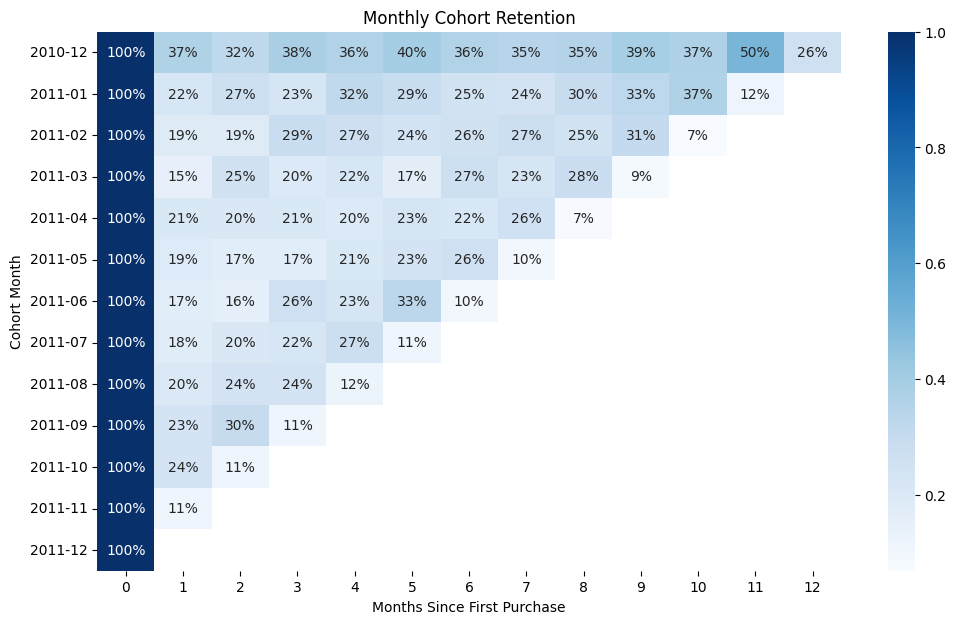

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,7))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Monthly Cohort Retention")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

#### Cohort Analysis
- Big question: Is there any monthly cohort performing worse or better than most cohorts?

### VIII. Market Basket Analysis

### IX. Model Development

### Feature Engineering:


In [ ]:
final_df.show(5)

+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-----------+-----+----+----------+------------+----+-------------+-------------------+-------------------+---------------------+----------------+-------+-------------+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|       Country|Customer_Type|Recency|Frequency|Monetary|Churn|day_of_week|month|year|month_year|quarter_year|hour|week_of_month|is_christmas_season|is_valentine_season|is_mothers_day_season|is_easter_season|Revenue|price_segment|
+----------+---------+---------+--------------------+--------+-------------------+---------+--------------+-------------+-------+---------+--------+-----+-----------+-----+----+----------+------------+----+-------------+-------------------+-------------------+---------------------+----------------+-------+-------------+
|     12346|   541431|    23166|ME

In [ ]:
# ============================================================
# 0. IMPORTS
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
from pyspark.ml.functions import vector_to_array

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator


# ============================================================
# 1. CONFIG
# ============================================================

LOOKBACK_DAYS = 180
PREDICTION_HORIZON = 30

LABEL_COL = "inactive_next_30d"


# ============================================================
# 2. START FROM final_df
#    final_df = ORDER LINE ITEM LEVEL
# ============================================================

# Remove old leakage-prone columns.
drop_cols = [
    "Churn",
    "Recency",
    "Frequency",
    "Monetary"
]

existing_drop_cols = [
    c for c in drop_cols
    if c in final_df.columns
]

line_df = (
    final_df
    .drop(*existing_drop_cols)

    # Identified customers only
    .filter(F.col("CustomerID").isNotNull())

    # Positive purchase only
    .filter(F.col("Quantity") > 0)
    .filter(F.col("UnitPrice") > 0)

    # Date
    .withColumn(
        "transaction_date",
        F.to_date("InvoiceDate")
    )
)

if "Customer_Type" in line_df.columns:
    line_df = line_df.filter(
        F.col("Customer_Type") == "Identified"
    )


# ============================================================
# 3. CREATE REVENUE IF NEEDED
# ============================================================

if "Revenue" not in line_df.columns:

    line_df = (
        line_df
        .withColumn(
            "Revenue",
            F.col("Quantity")
            * F.col("UnitPrice")
        )
    )


# Keep only columns needed downstream.
# Important for Spark performance.

line_df = line_df.select(
    "CustomerID",
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "transaction_date",
    "is_christmas_season",
    "is_valentine_season",
    "is_mothers_day_season",
    "is_easter_season"
)


# ============================================================
# 4. LINE ITEM -> ORDER LEVEL
# ============================================================

# THIS IS THE IMPORTANT OPTIMIZATION.
#
# Instead of:
# 500k product lines × snapshots
#
# We first reduce to:
# CustomerID × InvoiceNo

orders = (
    line_df

    .groupBy(
        "CustomerID",
        "InvoiceNo"
    )

    .agg(

        # One date per invoice
        F.min(
            "transaction_date"
        ).alias("order_date"),

        # Total order value
        F.sum(
            "Revenue"
        ).alias("order_revenue"),

        # Total units
        F.sum(
            "Quantity"
        ).alias("order_units"),

        # Number of unique SKUs inside order
        F.countDistinct(
            "StockCode"
        ).alias("order_products"),

        # Average item unit price in order
        F.avg(
            "UnitPrice"
        ).alias("avg_item_price"),

        # Seasonal flags
        F.max(
            "is_christmas_season"
        ).alias("is_christmas_season"),

        F.max(
            "is_valentine_season"
        ).alias("is_valentine_season"),

        F.max(
            "is_mothers_day_season"
        ).alias("is_mothers_day_season"),

        F.max(
            "is_easter_season"
        ).alias("is_easter_season")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger cache ONCE
n_orders = orders.count()

print("Number of orders:", n_orders)


# ============================================================
# 5. DATE RANGE
# ============================================================

date_info = (
    orders
    .agg(
        F.min(
            "order_date"
        ).alias("min_date"),

        F.max(
            "order_date"
        ).alias("max_date")
    )
    .first()
)

min_date = date_info["min_date"]
max_date = date_info["max_date"]

print(
    "Data range:",
    min_date,
    "to",
    max_date
)


# ============================================================
# 6. SNAPSHOT BOUNDARIES
# ============================================================

# Need:
#
# 180 days history before snapshot
# +
# 30 days future after snapshot
#
#
# Data:
#
# Dec 2010 ------------------------------ Dec 2011
#
#        <---180d---> T <---30d--->
#

bounds = (
    spark
    .createDataFrame(
        [(min_date, max_date)],
        ["min_date", "max_date"]
    )

    .select(

        F.date_add(
            "min_date",
            LOOKBACK_DAYS
        ).alias(
            "first_valid_date"
        ),

        F.date_sub(
            "max_date",
            PREDICTION_HORIZON
        ).alias(
            "last_valid_date"
        )
    )
)

bounds.show()


# ============================================================
# 7. CREATE CORRECT MONTHLY SNAPSHOTS
# ============================================================

# Example:
#
# first_valid_date = 2011-05-30
#
# May 1 is invalid because it doesn't have 180 days.
#
# Therefore first monthly snapshot = June 1.

snapshots = (
    bounds

    .select(
        F.explode(
            F.sequence(

                # First day of NEXT month
                F.add_months(
                    F.trunc(
                        "first_valid_date",
                        "month"
                    ),
                    1
                ),

                # First day of final valid month
                F.trunc(
                    "last_valid_date",
                    "month"
                ),

                F.expr(
                    "interval 1 month"
                )
            )
        ).alias(
            "snapshot_date"
        )
    )
)

print("Snapshots:")

snapshots.orderBy(
    "snapshot_date"
).show(
    truncate=False
)


# Expected for your data:
#
# 2011-06-01
# 2011-07-01
# 2011-08-01
# 2011-09-01
# 2011-10-01
# 2011-11-01


# ============================================================
# 8. FIRST PURCHASE PER CUSTOMER
# ============================================================

first_purchase = (
    orders
    .groupBy(
        "CustomerID"
    )
    .agg(
        F.min(
            "order_date"
        ).alias(
            "first_purchase_date"
        )
    )
)


# ============================================================
# 9. CUSTOMER × SNAPSHOT
# ============================================================

# Each row means:
#
# "What did Customer X look like at date T?"

customer_snapshots = (
    first_purchase

    # snapshots is tiny -> broadcast
    .crossJoin(
        F.broadcast(
            snapshots
        )
    )

    # Customer must already exist before snapshot
    .filter(
        F.col("first_purchase_date")
        < F.col("snapshot_date")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

n_customer_snapshots = (
    customer_snapshots.count()
)

print(
    "Customer-snapshot observations:",
    n_customer_snapshots
)


# ============================================================
# 10. HISTORICAL ORDER WINDOW
# ============================================================

# Only orders BEFORE snapshot
# within previous 180 days.

history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        orders.alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                <
                F.col("s.snapshot_date")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    LOOKBACK_DAYS
                )
            )
        ),

        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger once
history.count()


# ============================================================
# 11. CUSTOMER FEATURES
#
# ALL MAIN AGGREGATIONS IN ONE GROUPBY
# ============================================================

customer_features = (
    history

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        # ====================================================
        # LAST PURCHASE
        # ====================================================

        F.max(
            "o.order_date"
        ).alias(
            "last_purchase_date"
        ),


        # ====================================================
        # FREQUENCY
        # ====================================================

        F.count(
            "o.InvoiceNo"
        ).alias(
            "orders_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_90d"
        ),


        # ====================================================
        # REVENUE
        # ====================================================

        F.sum(
            "o.order_revenue"
        ).alias(
            "revenue_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_90d"
        ),


        # ====================================================
        # BASKET BEHAVIOR
        # ====================================================

        F.avg(
            "o.order_revenue"
        ).alias(
            "avg_order_value"
        ),

        F.avg(
            "o.order_units"
        ).alias(
            "avg_units_per_order"
        ),

        F.avg(
            "o.order_products"
        ).alias(
            "avg_products_per_order"
        ),

        F.max(
            "o.order_revenue"
        ).alias(
            "max_order_value"
        ),


        # ====================================================
        # CURRENT 30 DAYS VS PREVIOUS 30 DAYS
        # ====================================================

        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "current_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "previous_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                1
            ).otherwise(0)
        ).alias(
            "previous_30d_orders"
        ),


        # ====================================================
        # SEASONAL DEPENDENCY
        # ====================================================

        F.avg(
            "o.is_christmas_season"
        ).alias(
            "christmas_purchase_share"
        ),

        F.avg(
            "o.is_valentine_season"
        ).alias(
            "valentine_purchase_share"
        ),

        F.avg(
            "o.is_mothers_day_season"
        ).alias(
            "mothers_day_purchase_share"
        ),

        F.avg(
            "o.is_easter_season"
        ).alias(
            "easter_purchase_share"
        )
    )
)


# ============================================================
# 12. RECENCY + TRENDS
# ============================================================

customer_features = (
    customer_features

    .withColumn(
        "recency",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "last_purchase_date"
            )
        )
    )

    .withColumn(
        "revenue_change_30d",

        F.col(
            "current_30d_revenue"
        )
        -
        F.col(
            "previous_30d_revenue"
        )
    )

    .withColumn(
        "order_change_30d",

        F.col(
            "orders_30d"
        )
        -
        F.col(
            "previous_30d_orders"
        )
    )
)


# ============================================================
# 13. INTER-ORDER GAP
# ============================================================

# Sort historical orders per:
# Customer × Snapshot

gap_window = (
    Window

    .partitionBy(
        F.col(
            "s.CustomerID"
        ),
        F.col(
            "s.snapshot_date"
        )
    )

    .orderBy(
        F.col(
            "o.order_date"
        )
    )
)


history_with_gap = (
    history

    .withColumn(
        "previous_order_date",

        F.lag(
            "o.order_date"
        ).over(
            gap_window
        )
    )

    .withColumn(
        "order_gap",

        F.datediff(
            F.col(
                "o.order_date"
            ),
            F.col(
                "previous_order_date"
            )
        )
    )
)


gap_features = (
    history_with_gap

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        F.avg(
            "order_gap"
        ).alias(
            "avg_order_gap"
        ),

        F.expr(
            """
            percentile_approx(
                order_gap,
                0.5
            )
            """
        ).alias(
            "median_order_gap"
        ),

        F.stddev(
            "order_gap"
        ).alias(
            "std_order_gap"
        )
    )
)


# ============================================================
# 14. FUTURE 30-DAY LABEL
# ============================================================

# THIS IS THE Y.
#
# At snapshot T:
#
# Customer buys in next 30d
# -> 0
#
# Customer DOES NOT buy in next 30d
# -> 1

future_behavior = (
    customer_snapshots

    .select(
        "CustomerID",
        "snapshot_date"
    )

    .alias("s")

    .join(
        orders
        .select(
            "CustomerID",
            "InvoiceNo",
            "order_date"
        )
        .alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.col(
                    "s.snapshot_date"
                )
            )
            &
            (
                F.col("o.order_date")
                <
                F.date_add(
                    F.col(
                        "s.snapshot_date"
                    ),
                    PREDICTION_HORIZON
                )
            )
        ),

        "left"
    )

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(
        F.count(
            "o.InvoiceNo"
        ).alias(
            "future_orders_30d"
        )
    )

    .withColumn(
        LABEL_COL,

        F.when(
            F.col(
                "future_orders_30d"
            ) == 0,
            1
        ).otherwise(0)
    )
)


# ============================================================
# 15. FINAL MODEL DATASET
# ============================================================

model_df = (
    customer_features

    .join(
        gap_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        future_behavior.select(
            "CustomerID",
            "snapshot_date",
            LABEL_COL
        ),
        [
            "CustomerID",
            "snapshot_date"
        ],
        "inner"
    )

    .join(
        first_purchase,
        "CustomerID",
        "left"
    )

    .withColumn(
        "customer_age_days",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "first_purchase_date"
            )
        )
    )

    # Relative lateness
    .withColumn(
        "recency_gap_ratio",

        F.when(
            F.col(
                "median_order_gap"
            ) > 0,

            F.col(
                "recency"
            )
            /
            F.col(
                "median_order_gap"
            )
        )
    )
)


# ============================================================
# 16. FEATURE LIST
# ============================================================

feature_cols = [

    # Recency
    "recency",

    # Frequency
    "orders_30d",
    "orders_60d",
    "orders_90d",
    "orders_180d",

    # Monetary
    "revenue_30d",
    "revenue_60d",
    "revenue_90d",
    "revenue_180d",

    # Basket
    "avg_order_value",
    "avg_units_per_order",
    "avg_products_per_order",
    "max_order_value",

    # Purchase rhythm
    "avg_order_gap",
    "median_order_gap",
    "std_order_gap",
    "recency_gap_ratio",

    # Trend
    "revenue_change_30d",
    "order_change_30d",

    # Customer lifecycle
    "customer_age_days",

    # Seasonal dependence
    "christmas_purchase_share",
    "valentine_purchase_share",
    "mothers_day_purchase_share",
    "easter_purchase_share"
]


# ============================================================
# 17. NULL HANDLING
# ============================================================

model_df = (
    model_df

    # Need at least one historical purchase
    .filter(
        F.col(
            "recency"
        ).isNotNull()
    )

    .fillna(
        0,
        subset=feature_cols
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)


# Trigger final feature table ONCE
n_model = model_df.count()

print(
    "Final modeling observations:",
    n_model
)


# ============================================================
# 18. INSPECT DATA
# ============================================================

model_df.select(

    "CustomerID",
    "snapshot_date",

    "recency",

    "orders_30d",
    "orders_90d",

    "revenue_90d",

    "avg_order_value",

    "median_order_gap",
    "recency_gap_ratio",

    LABEL_COL

).orderBy(
    "snapshot_date",
    "CustomerID"
).show(
    30,
    truncate=False
)


# ============================================================
# 19. LABEL DISTRIBUTION
# ============================================================

model_df.groupBy(
    LABEL_COL
).count().show()


# ============================================================
# 20. LABEL DISTRIBUTION BY SNAPSHOT
# ============================================================

snapshot_summary = (
    model_df

    .groupBy(
        "snapshot_date"
    )

    .agg(

        F.count(
            "*"
        ).alias(
            "customers"
        ),

        F.avg(
            LABEL_COL
        ).alias(
            "inactive_rate_30d"
        )
    )

    .orderBy(
        "snapshot_date"
    )
)

snapshot_summary.show(
    truncate=False
)


# ============================================================
# 21. TIME-BASED SPLIT
# ============================================================

snapshot_dates = [

    row["snapshot_date"]

    for row in (
        model_df
        .select(
            "snapshot_date"
        )
        .distinct()
        .orderBy(
            "snapshot_date"
        )
        .collect()
    )
]

print(
    "Snapshots:",
    snapshot_dates
)


if len(snapshot_dates) < 3:

    raise ValueError(
        "Need at least 3 snapshots."
    )


# Latest = OOT test
test_date = snapshot_dates[-1]

# Second latest = validation
valid_date = snapshot_dates[-2]


train_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        <
        F.lit(
            valid_date
        )
    )
)


valid_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            valid_date
        )
    )
)


test_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            test_date
        )
    )
)


print(
    "Validation:",
    valid_date
)

print(
    "OOT Test:",
    test_date
)


# Since model_df is cached,
# these counts are cheap.

print(
    "Train rows:",
    train_df.count()
)

print(
    "Validation rows:",
    valid_df.count()
)

print(
    "Test rows:",
    test_df.count()
)


# ============================================================
# 22. BASELINE
# ============================================================

# Important because class 1 is majority.
#
# Naive model predicts EVERYONE inactive.

# ============================================================
# BASELINE
# ============================================================

for name, data in [
    ("Train", train_df),
    ("Validation", valid_df),
    ("OOT Test", test_df)
]:

    result = (
        data
        .agg(
            F.avg(LABEL_COL).alias("positive_rate")
        )
        .first()
    )

    positive_rate = float(result["positive_rate"])

    # Majority-class baseline
    naive_accuracy = (
        positive_rate
        if positive_rate >= 0.5
        else 1.0 - positive_rate
    )

    print(
        f"{name}: "
        f"positive_rate={positive_rate:.4f} | "
        f"naive_accuracy={naive_accuracy:.4f}"
    )

# ============================================================
# 23. VECTOR ASSEMBLER
# ============================================================

assembler = VectorAssembler(

    inputCols=feature_cols,

    outputCol="features",

    handleInvalid="keep"
)


# ============================================================
# 24. EVALUATORS
# ============================================================

roc_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderROC"
    )
)


pr_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderPR"
    )
)


# ============================================================
# 25. METRIC FUNCTION - FIXED
# ============================================================

def evaluate_model(predictions, name="Model"):

    counts = (
        predictions
        .groupBy(LABEL_COL, "prediction")
        .count()
        .collect()
    )

    cm = {
        (int(row[LABEL_COL]), int(row["prediction"])): int(row["count"])
        for row in counts
    }

    TN = cm.get((0, 0), 0)
    FP = cm.get((0, 1), 0)
    FN = cm.get((1, 0), 0)
    TP = cm.get((1, 1), 0)

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    roc_auc = float(roc_evaluator.evaluate(predictions))
    pr_auc = float(pr_evaluator.evaluate(predictions))

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"PR-AUC     : {pr_auc:.4f}")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1         : {f1:.4f}")

    print("\nConfusion Matrix")
    print(f"TP: {TP} | FP: {FP}")
    print(f"FN: {FN} | TN: {TN}")

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    }


# ============================================================
# 26. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.01
)

lr_pipeline = Pipeline(
    stages=[
        assembler,
        lr
    ]
)

lr_model = lr_pipeline.fit(train_df)

lr_train_pred = lr_model.transform(train_df)
lr_valid_pred = lr_model.transform(valid_df)
lr_test_pred = lr_model.transform(test_df)


# ============================================================
# 27. LR METRICS - TRAIN / VALIDATION / OOT
# ============================================================

lr_train_metrics = evaluate_model(
    lr_train_pred,
    "LR - TRAIN"
)

lr_valid_metrics = evaluate_model(
    lr_valid_pred,
    "LR - VALIDATION"
)

lr_test_metrics = evaluate_model(
    lr_test_pred,
    "LR - OOT TEST"
)


# ============================================================
# 28. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=7,
    minInstancesPerNode=10,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        assembler,
        rf
    ]
)

rf_model = rf_pipeline.fit(train_df)

rf_train_pred = rf_model.transform(train_df)
rf_valid_pred = rf_model.transform(valid_df)
rf_test_pred = rf_model.transform(test_df)


# ============================================================
# 29. RF METRICS - TRAIN / VALIDATION / OOT
# ============================================================

rf_train_metrics = evaluate_model(
    rf_train_pred,
    "RF - TRAIN"
)

rf_valid_metrics = evaluate_model(
    rf_valid_pred,
    "RF - VALIDATION"
)

rf_test_metrics = evaluate_model(
    rf_test_pred,
    "RF - OOT TEST"
)


# ============================================================
# 30. MODEL COMPARISON
# ============================================================

comparison_data = [
    ("LR", "Train", lr_train_metrics["roc_auc"], lr_train_metrics["pr_auc"], lr_train_metrics["accuracy"], lr_train_metrics["precision"], lr_train_metrics["recall"], lr_train_metrics["specificity"], lr_train_metrics["f1"]),
    ("LR", "Validation", lr_valid_metrics["roc_auc"], lr_valid_metrics["pr_auc"], lr_valid_metrics["accuracy"], lr_valid_metrics["precision"], lr_valid_metrics["recall"], lr_valid_metrics["specificity"], lr_valid_metrics["f1"]),
    ("LR", "OOT Test", lr_test_metrics["roc_auc"], lr_test_metrics["pr_auc"], lr_test_metrics["accuracy"], lr_test_metrics["precision"], lr_test_metrics["recall"], lr_test_metrics["specificity"], lr_test_metrics["f1"]),
    ("RF", "Train", rf_train_metrics["roc_auc"], rf_train_metrics["pr_auc"], rf_train_metrics["accuracy"], rf_train_metrics["precision"], rf_train_metrics["recall"], rf_train_metrics["specificity"], rf_train_metrics["f1"]),
    ("RF", "Validation", rf_valid_metrics["roc_auc"], rf_valid_metrics["pr_auc"], rf_valid_metrics["accuracy"], rf_valid_metrics["precision"], rf_valid_metrics["recall"], rf_valid_metrics["specificity"], rf_valid_metrics["f1"]),
    ("RF", "OOT Test", rf_test_metrics["roc_auc"], rf_test_metrics["pr_auc"], rf_test_metrics["accuracy"], rf_test_metrics["precision"], rf_test_metrics["recall"], rf_test_metrics["specificity"], rf_test_metrics["f1"])
]

comparison_df = spark.createDataFrame(
    comparison_data,
    [
        "model",
        "dataset",
        "roc_auc",
        "pr_auc",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "f1"
    ]
)

print("\nMODEL COMPARISON")
comparison_df.show(truncate=False)


# ============================================================
# 31. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_stage = rf_model.stages[-1]
rf_importances = rf_stage.featureImportances

importance_data = [
    (
        feature_cols[i],
        float(rf_importances[i])
    )
    for i in range(len(feature_cols))
]

importance_df = spark.createDataFrame(
    importance_data,
    ["feature", "importance"]
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")

importance_df.orderBy(
    F.desc("importance")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 32. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

lr_stage = lr_model.stages[-1]
lr_coefficients = lr_stage.coefficients

lr_coef_data = [
    (
        feature_cols[i],
        float(lr_coefficients[i])
    )
    for i in range(len(feature_cols))
]

lr_coef_df = spark.createDataFrame(
    lr_coef_data,
    ["feature", "coefficient"]
)

print("\nLOGISTIC REGRESSION COEFFICIENTS")

lr_coef_df.withColumn(
    "abs_coefficient",
    F.abs("coefficient")
).orderBy(
    F.desc("abs_coefficient")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 33. TEST RISK SCORES
# ============================================================

rf_risk_scores = (
    rf_test_pred

    .withColumn(
        "probability_array",
        vector_to_array(
            F.col("probability")
        )
    )

    .withColumn(
        "inactivity_probability",
        F.col("probability_array")[1]
    )

    .select(
        "CustomerID",
        "snapshot_date",
        "recency",
        "orders_30d",
        "orders_90d",
        "revenue_90d",
        "median_order_gap",
        "recency_gap_ratio",
        LABEL_COL,
        "prediction",
        "inactivity_probability"
    )
)

print("\nTOP HIGH-RISK CUSTOMERS")

rf_risk_scores.orderBy(
    F.desc("inactivity_probability")
).show(
    50,
    truncate=False
)


# ============================================================
# 34. RISK DECILES
# ============================================================

risk_window = (
    Window
    .orderBy(
        F.desc("inactivity_probability")
    )
)

risk_deciles = (
    rf_risk_scores
    .withColumn(
        "risk_decile",
        F.ntile(10).over(risk_window)
    )
)

decile_summary = (
    risk_deciles
    .groupBy("risk_decile")
    .agg(
        F.count("*").alias("customers"),
        F.avg("inactivity_probability").alias(
            "avg_predicted_risk"
        ),
        F.avg(LABEL_COL).alias(
            "actual_inactive_rate"
        )
    )
    .orderBy("risk_decile")
)

print("\nRISK DECILES")
decile_summary.show(
    10,
    truncate=False
)


# ============================================================
# 35. TOP 20% LIFT - FIXED
# ============================================================

total_stats = (
    rf_risk_scores
    .agg(
        F.count("*").alias("N"),
        F.sum(LABEL_COL).alias(
            "total_inactive"
        )
    )
    .first()
)

N = int(total_stats["N"])
total_inactive = float(
    total_stats["total_inactive"]
)

top_20_n = int(N * 0.20)

top20 = (
    rf_risk_scores
    .orderBy(
        F.desc(
            "inactivity_probability"
        )
    )
    .limit(top_20_n)
)

top20_stats = (
    top20
    .agg(
        F.count("*").alias("customers"),
        F.sum(LABEL_COL).alias("inactive"),
        F.avg(LABEL_COL).alias("inactive_rate")
    )
    .first()
)

overall_rate = (
    total_inactive / N
    if N > 0 else 0.0
)

top20_rate = (
    float(top20_stats["inactive_rate"])
    if top20_stats["inactive_rate"] is not None
    else 0.0
)

lift_top20 = (
    top20_rate / overall_rate
    if overall_rate > 0
    else 0.0
)

capture_top20 = (
    float(top20_stats["inactive"]) / total_inactive
    if total_inactive > 0
    else 0.0
)

print("\nTOP 20% BUSINESS PERFORMANCE")
print(f"Overall inactivity rate: {overall_rate:.4f}")
print(f"Top 20% inactivity rate: {top20_rate:.4f}")
print(f"Lift@20%: {lift_top20:.4f}")
print(f"Capture rate@20%: {capture_top20:.4f}")


# ============================================================
# 36. OPTIONAL: UNPERSIST LARGE INTERMEDIATE TABLES
# ============================================================

history.unpersist()
customer_snapshots.unpersist()
orders.unpersist()

# Keep model_df cached while doing experiments.


Number of orders: 18402
Data range: 2010-12-01 to 2011-12-09
+----------------+---------------+
|first_valid_date|last_valid_date|
+----------------+---------------+
|      2011-05-30|     2011-11-09|
+----------------+---------------+

Snapshots:
+-------------+
|snapshot_date|
+-------------+
|2011-06-01   |
|2011-07-01   |
|2011-08-01   |
|2011-09-01   |
|2011-10-01   |
|2011-11-01   |
+-------------+

Customer-snapshot observations: 19716
Final modeling observations: 17021
+----------+-------------+-------+----------+----------+------------------+------------------+----------------+------------------+-----------------+
|CustomerID|snapshot_date|recency|orders_30d|orders_90d|revenue_90d       |avg_order_value   |median_order_gap|recency_gap_ratio |inactive_next_30d|
+----------+-------------+-------+----------+----------+------------------+------------------+----------------+------------------+-----------------+
|12346     |2011-06-01   |134    |0         |0         |0.0            

DataFrame[CustomerID: int, InvoiceNo: string, order_date: date, order_revenue: double, order_units: bigint, order_products: bigint, avg_item_price: double, is_christmas_season: int, is_valentine_season: int, is_mothers_day_season: int, is_easter_season: int]

In [ ]:
# ============================================================
# 0. IMPORTS
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
from pyspark.ml.functions import vector_to_array

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator


# ============================================================
# 1. CONFIG
# ============================================================

LOOKBACK_DAYS = 180
PREDICTION_HORIZON = 30

LABEL_COL = "inactive_next_30d"


# ============================================================
# 2. START FROM final_df
#    final_df = ORDER LINE ITEM LEVEL
# ============================================================

# Remove old leakage-prone columns.
drop_cols = [
    "Churn",
    "Recency",
    "Frequency",
    "Monetary"
]

existing_drop_cols = [
    c for c in drop_cols
    if c in final_df.columns
]

line_df = (
    final_df
    .drop(*existing_drop_cols)

    # Identified customers only
    .filter(F.col("CustomerID").isNotNull())

    # Positive purchase only
    .filter(F.col("Quantity") > 0)
    .filter(F.col("UnitPrice") > 0)

    # Date
    .withColumn(
        "transaction_date",
        F.to_date("InvoiceDate")
    )
)

if "Customer_Type" in line_df.columns:
    line_df = line_df.filter(
        F.col("Customer_Type") == "Identified"
    )


# ============================================================
# 3. CREATE REVENUE IF NEEDED
# ============================================================

if "Revenue" not in line_df.columns:

    line_df = (
        line_df
        .withColumn(
            "Revenue",
            F.col("Quantity")
            * F.col("UnitPrice")
        )
    )


# Keep only columns needed downstream.
# Important for Spark performance.

line_df = line_df.select(
    "CustomerID",
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "transaction_date",
    "is_christmas_season",
    "is_valentine_season",
    "is_mothers_day_season",
    "is_easter_season"
)


# ============================================================
# 4. LINE ITEM -> ORDER LEVEL
# ============================================================

# THIS IS THE IMPORTANT OPTIMIZATION.
#
# Instead of:
# 500k product lines × snapshots
#
# We first reduce to:
# CustomerID × InvoiceNo

orders = (
    line_df

    .groupBy(
        "CustomerID",
        "InvoiceNo"
    )

    .agg(

        # One date per invoice
        F.min(
            "transaction_date"
        ).alias("order_date"),

        # Total order value
        F.sum(
            "Revenue"
        ).alias("order_revenue"),

        # Total units
        F.sum(
            "Quantity"
        ).alias("order_units"),

        # Number of unique SKUs inside order
        F.countDistinct(
            "StockCode"
        ).alias("order_products"),

        # Average item unit price in order
        F.avg(
            "UnitPrice"
        ).alias("avg_item_price"),

        # Seasonal flags
        F.max(
            "is_christmas_season"
        ).alias("is_christmas_season"),

        F.max(
            "is_valentine_season"
        ).alias("is_valentine_season"),

        F.max(
            "is_mothers_day_season"
        ).alias("is_mothers_day_season"),

        F.max(
            "is_easter_season"
        ).alias("is_easter_season")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger cache ONCE
n_orders = orders.count()

print("Number of orders:", n_orders)


# ============================================================
# 5. DATE RANGE
# ============================================================

date_info = (
    orders
    .agg(
        F.min(
            "order_date"
        ).alias("min_date"),

        F.max(
            "order_date"
        ).alias("max_date")
    )
    .first()
)

min_date = date_info["min_date"]
max_date = date_info["max_date"]

print(
    "Data range:",
    min_date,
    "to",
    max_date
)


# ============================================================
# 6. SNAPSHOT BOUNDARIES
# ============================================================

# Need:
#
# 180 days history before snapshot
# +
# 30 days future after snapshot
#
#
# Data:
#
# Dec 2010 ------------------------------ Dec 2011
#
#        <---180d---> T <---30d--->
#

bounds = (
    spark
    .createDataFrame(
        [(min_date, max_date)],
        ["min_date", "max_date"]
    )

    .select(

        F.date_add(
            "min_date",
            LOOKBACK_DAYS
        ).alias(
            "first_valid_date"
        ),

        F.date_sub(
            "max_date",
            PREDICTION_HORIZON
        ).alias(
            "last_valid_date"
        )
    )
)

bounds.show()


# ============================================================
# 7. CREATE CORRECT MONTHLY SNAPSHOTS
# ============================================================

# Example:
#
# first_valid_date = 2011-05-30
#
# May 1 is invalid because it doesn't have 180 days.
#
# Therefore first monthly snapshot = June 1.

snapshots = (
    bounds

    .select(
        F.explode(
            F.sequence(

                # First day of NEXT month
                F.add_months(
                    F.trunc(
                        "first_valid_date",
                        "month"
                    ),
                    1
                ),

                # First day of final valid month
                F.trunc(
                    "last_valid_date",
                    "month"
                ),

                F.expr(
                    "interval 1 month"
                )
            )
        ).alias(
            "snapshot_date"
        )
    )
)

print("Snapshots:")

snapshots.orderBy(
    "snapshot_date"
).show(
    truncate=False
)


# Expected for your data:
#
# 2011-06-01
# 2011-07-01
# 2011-08-01
# 2011-09-01
# 2011-10-01
# 2011-11-01


# ============================================================
# 8. FIRST PURCHASE PER CUSTOMER
# ============================================================

first_purchase = (
    orders
    .groupBy(
        "CustomerID"
    )
    .agg(
        F.min(
            "order_date"
        ).alias(
            "first_purchase_date"
        )
    )
)


# ============================================================
# 9. CUSTOMER × SNAPSHOT
# ============================================================

# Each row means:
#
# "What did Customer X look like at date T?"

customer_snapshots = (
    first_purchase

    # snapshots is tiny -> broadcast
    .crossJoin(
        F.broadcast(
            snapshots
        )
    )

    # Customer must already exist before snapshot
    .filter(
        F.col("first_purchase_date")
        < F.col("snapshot_date")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

n_customer_snapshots = (
    customer_snapshots.count()
)

print(
    "Customer-snapshot observations:",
    n_customer_snapshots
)


# ============================================================
# 10. HISTORICAL ORDER WINDOW
# ============================================================

# Only orders BEFORE snapshot
# within previous 180 days.

history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        orders.alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                <
                F.col("s.snapshot_date")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    LOOKBACK_DAYS
                )
            )
        ),

        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger once
history.count()


# ============================================================
# 11. CUSTOMER FEATURES
#
# ALL MAIN AGGREGATIONS IN ONE GROUPBY
# ============================================================

customer_features = (
    history

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        # ====================================================
        # LAST PURCHASE
        # ====================================================

        F.max(
            "o.order_date"
        ).alias(
            "last_purchase_date"
        ),


        # ====================================================
        # FREQUENCY
        # ====================================================

        F.count(
            "o.InvoiceNo"
        ).alias(
            "orders_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_90d"
        ),


        # ====================================================
        # REVENUE
        # ====================================================

        F.sum(
            "o.order_revenue"
        ).alias(
            "revenue_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_90d"
        ),


        # ====================================================
        # BASKET BEHAVIOR
        # ====================================================

        F.avg(
            "o.order_revenue"
        ).alias(
            "avg_order_value"
        ),

        F.avg(
            "o.order_units"
        ).alias(
            "avg_units_per_order"
        ),

        F.avg(
            "o.order_products"
        ).alias(
            "avg_products_per_order"
        ),

        F.max(
            "o.order_revenue"
        ).alias(
            "max_order_value"
        ),


        # ====================================================
        # CURRENT 30 DAYS VS PREVIOUS 30 DAYS
        # ====================================================

        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "current_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "previous_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                1
            ).otherwise(0)
        ).alias(
            "previous_30d_orders"
        ),


        # ====================================================
        # SEASONAL DEPENDENCY
        # ====================================================

        F.avg(
            "o.is_christmas_season"
        ).alias(
            "christmas_purchase_share"
        ),

        F.avg(
            "o.is_valentine_season"
        ).alias(
            "valentine_purchase_share"
        ),

        F.avg(
            "o.is_mothers_day_season"
        ).alias(
            "mothers_day_purchase_share"
        ),

        F.avg(
            "o.is_easter_season"
        ).alias(
            "easter_purchase_share"
        )
    )
)


# ============================================================
# 12. RECENCY + TRENDS
# ============================================================

customer_features = (
    customer_features

    .withColumn(
        "recency",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "last_purchase_date"
            )
        )
    )

    .withColumn(
        "revenue_change_30d",

        F.col(
            "current_30d_revenue"
        )
        -
        F.col(
            "previous_30d_revenue"
        )
    )

    .withColumn(
        "order_change_30d",

        F.col(
            "orders_30d"
        )
        -
        F.col(
            "previous_30d_orders"
        )
    )
)


# ============================================================
# 13. INTER-ORDER GAP
# ============================================================

# Sort historical orders per:
# Customer × Snapshot

gap_window = (
    Window

    .partitionBy(
        F.col(
            "s.CustomerID"
        ),
        F.col(
            "s.snapshot_date"
        )
    )

    .orderBy(
        F.col(
            "o.order_date"
        )
    )
)


history_with_gap = (
    history

    .withColumn(
        "previous_order_date",

        F.lag(
            "o.order_date"
        ).over(
            gap_window
        )
    )

    .withColumn(
        "order_gap",

        F.datediff(
            F.col(
                "o.order_date"
            ),
            F.col(
                "previous_order_date"
            )
        )
    )
)


gap_features = (
    history_with_gap

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        F.avg(
            "order_gap"
        ).alias(
            "avg_order_gap"
        ),

        F.expr(
            """
            percentile_approx(
                order_gap,
                0.5
            )
            """
        ).alias(
            "median_order_gap"
        ),

        F.stddev(
            "order_gap"
        ).alias(
            "std_order_gap"
        )
    )
)


# ============================================================
# 14. V2 PRODUCT DIVERSITY FEATURES
# ============================================================
# IMPORTANT:
# avg_products_per_order measures basket breadth per invoice.
# The features below measure TRUE customer-level product diversity
# across the historical window.

product_history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        line_df
        .select(
            "CustomerID",
            "InvoiceNo",
            "StockCode",
            "transaction_date"
        )
        .alias("p"),

        (
            (F.col("s.CustomerID") == F.col("p.CustomerID"))
            &
            (F.col("p.transaction_date") < F.col("s.snapshot_date"))
            &
            (
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    LOOKBACK_DAYS
                )
            )
        ),
        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Count how many distinct invoices each SKU appeared in
# for each Customer x Snapshot.
product_by_sku = (
    product_history

    .filter(
        F.col("p.StockCode").isNotNull()
    )

    .groupBy(
        F.col("s.CustomerID").alias("CustomerID"),
        F.col("s.snapshot_date").alias("snapshot_date"),
        F.col("p.StockCode").alias("StockCode")
    )

    .agg(
        F.countDistinct(
            "p.InvoiceNo"
        ).alias(
            "sku_orders_180d"
        ),

        F.max(
            F.when(
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "bought_in_30d"
        ),

        F.max(
            F.when(
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "bought_in_90d"
        )
    )
)

product_features = (
    product_by_sku

    .groupBy(
        "CustomerID",
        "snapshot_date"
    )

    .agg(
        # TRUE customer-level distinct products
        F.countDistinct(
            "StockCode"
        ).alias(
            "distinct_products_180d"
        ),

        F.sum(
            "bought_in_30d"
        ).alias(
            "distinct_products_30d"
        ),

        F.sum(
            "bought_in_90d"
        ).alias(
            "distinct_products_90d"
        ),

        # Number of SKUs purchased in at least 2 separate invoices.
        F.sum(
            F.when(
                F.col("sku_orders_180d") >= 2,
                1
            ).otherwise(0)
        ).alias(
            "repeat_products_180d"
        )
    )

    # Fraction of distinct products that were repurchased.
    .withColumn(
        "repeat_product_ratio_180d",
        F.when(
            F.col("distinct_products_180d") > 0,
            F.col("repeat_products_180d")
            / F.col("distinct_products_180d")
        ).otherwise(0.0)
    )
)


# ============================================================
# 15. FUTURE 30-DAY LABEL
# ============================================================

# THIS IS THE Y.
#
# At snapshot T:
#
# Customer buys in next 30d
# -> 0
#
# Customer DOES NOT buy in next 30d
# -> 1

future_behavior = (
    customer_snapshots

    .select(
        "CustomerID",
        "snapshot_date"
    )

    .alias("s")

    .join(
        orders
        .select(
            "CustomerID",
            "InvoiceNo",
            "order_date"
        )
        .alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.col(
                    "s.snapshot_date"
                )
            )
            &
            (
                F.col("o.order_date")
                <
                F.date_add(
                    F.col(
                        "s.snapshot_date"
                    ),
                    PREDICTION_HORIZON
                )
            )
        ),

        "left"
    )

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(
        F.count(
            "o.InvoiceNo"
        ).alias(
            "future_orders_30d"
        )
    )

    .withColumn(
        LABEL_COL,

        F.when(
            F.col(
                "future_orders_30d"
            ) == 0,
            1
        ).otherwise(0)
    )
)


# ============================================================
# 16. FINAL MODEL DATASET
# ============================================================

model_df = (
    customer_features

    .join(
        gap_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        product_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        future_behavior.select(
            "CustomerID",
            "snapshot_date",
            LABEL_COL
        ),
        [
            "CustomerID",
            "snapshot_date"
        ],
        "inner"
    )

    .join(
        first_purchase,
        "CustomerID",
        "left"
    )

    .withColumn(
        "customer_age_days",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "first_purchase_date"
            )
        )
    )

    # V2: distinguish "no gap history" from a genuine zero-day gap.
    .withColumn(
        "has_gap_history",
        F.when(
            F.col("median_order_gap").isNotNull(),
            1
        ).otherwise(0)
    )

    # Relative lateness
    .withColumn(
        "recency_gap_ratio",

        F.when(
            F.col(
                "median_order_gap"
            ) > 0,

            F.col(
                "recency"
            )
            /
            F.col(
                "median_order_gap"
            )
        )
    )
)


# ============================================================
# 17. FEATURE LIST
# ============================================================

feature_cols = [

    # Recency
    "recency",

    # Frequency
    "orders_30d",
    "orders_60d",
    "orders_90d",
    "orders_180d",

    # Monetary
    "revenue_30d",
    "revenue_60d",
    "revenue_90d",
    "revenue_180d",

    # Basket
    "avg_order_value",
    "avg_units_per_order",
    "avg_products_per_order",
    "max_order_value",

    # V2: TRUE customer-level product diversity
    "distinct_products_30d",
    "distinct_products_90d",
    "distinct_products_180d",
    "repeat_product_ratio_180d",

    # Purchase rhythm
    "avg_order_gap",
    "median_order_gap",
    "std_order_gap",
    "recency_gap_ratio",
    "has_gap_history",

    # Trend
    "revenue_change_30d",
    "order_change_30d",

    # Customer lifecycle
    "customer_age_days",

    # Seasonal dependence
    "christmas_purchase_share",
    "valentine_purchase_share",
    "mothers_day_purchase_share",
    "easter_purchase_share"
]


# ============================================================
# 18. NULL HANDLING
# ============================================================

model_df = (
    model_df

    # Need at least one historical purchase
    .filter(
        F.col(
            "recency"
        ).isNotNull()
    )

    .fillna(
        0,
        subset=feature_cols
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)


# Trigger final feature table ONCE
n_model = model_df.count()

print(
    "Final modeling observations:",
    n_model
)


# ============================================================
# 19. INSPECT DATA
# ============================================================

model_df.select(

    "CustomerID",
    "snapshot_date",

    "recency",

    "orders_30d",
    "orders_90d",

    "revenue_90d",

    "avg_order_value",

    "distinct_products_90d",
    "distinct_products_180d",
    "repeat_product_ratio_180d",

    "median_order_gap",
    "has_gap_history",
    "recency_gap_ratio",

    LABEL_COL

).orderBy(
    "snapshot_date",
    "CustomerID"
).show(
    30,
    truncate=False
)


# ============================================================
# 20. LABEL DISTRIBUTION
# ============================================================

model_df.groupBy(
    LABEL_COL
).count().show()


# ============================================================
# 21. LABEL DISTRIBUTION BY SNAPSHOT
# ============================================================

snapshot_summary = (
    model_df

    .groupBy(
        "snapshot_date"
    )

    .agg(

        F.count(
            "*"
        ).alias(
            "customers"
        ),

        F.avg(
            LABEL_COL
        ).alias(
            "inactive_rate_30d"
        )
    )

    .orderBy(
        "snapshot_date"
    )
)

snapshot_summary.show(
    truncate=False
)


# ============================================================
# 22. TIME-BASED SPLIT
# ============================================================

snapshot_dates = [

    row["snapshot_date"]

    for row in (
        model_df
        .select(
            "snapshot_date"
        )
        .distinct()
        .orderBy(
            "snapshot_date"
        )
        .collect()
    )
]

print(
    "Snapshots:",
    snapshot_dates
)


if len(snapshot_dates) < 3:

    raise ValueError(
        "Need at least 3 snapshots."
    )


# Latest = OOT test
test_date = snapshot_dates[-1]

# Second latest = validation
valid_date = snapshot_dates[-2]


train_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        <
        F.lit(
            valid_date
        )
    )
)


valid_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            valid_date
        )
    )
)


test_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            test_date
        )
    )
)


print(
    "Validation:",
    valid_date
)

print(
    "OOT Test:",
    test_date
)


# Since model_df is cached,
# these counts are cheap.

print(
    "Train rows:",
    train_df.count()
)

print(
    "Validation rows:",
    valid_df.count()
)

print(
    "Test rows:",
    test_df.count()
)


# ============================================================
# 23. BASELINE
# ============================================================

# Important because class 1 is majority.
#
# Naive model predicts EVERYONE inactive.

# ============================================================
# BASELINE
# ============================================================

for name, data in [
    ("Train", train_df),
    ("Validation", valid_df),
    ("OOT Test", test_df)
]:

    result = (
        data
        .agg(
            F.avg(LABEL_COL).alias("positive_rate")
        )
        .first()
    )

    positive_rate = float(result["positive_rate"])

    # Majority-class baseline
    naive_accuracy = (
        positive_rate
        if positive_rate >= 0.5
        else 1.0 - positive_rate
    )

    print(
        f"{name}: "
        f"positive_rate={positive_rate:.4f} | "
        f"naive_accuracy={naive_accuracy:.4f}"
    )

# ============================================================
# 23. VECTOR ASSEMBLER
# ============================================================

assembler = VectorAssembler(

    inputCols=feature_cols,

    outputCol="features",

    handleInvalid="keep"
)


# ============================================================
# 24. EVALUATORS
# ============================================================

roc_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderROC"
    )
)


pr_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderPR"
    )
)


# ============================================================
# 25. METRIC FUNCTION - FIXED
# ============================================================

def evaluate_model(predictions, name="Model"):

    counts = (
        predictions
        .groupBy(LABEL_COL, "prediction")
        .count()
        .collect()
    )

    cm = {
        (int(row[LABEL_COL]), int(row["prediction"])): int(row["count"])
        for row in counts
    }

    TN = cm.get((0, 0), 0)
    FP = cm.get((0, 1), 0)
    FN = cm.get((1, 0), 0)
    TP = cm.get((1, 1), 0)

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    roc_auc = float(roc_evaluator.evaluate(predictions))
    pr_auc = float(pr_evaluator.evaluate(predictions))

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"PR-AUC     : {pr_auc:.4f}")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1         : {f1:.4f}")

    print("\nConfusion Matrix")
    print(f"TP: {TP} | FP: {FP}")
    print(f"FN: {FN} | TN: {TN}")

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    }


# ============================================================
# 26. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.01
)

lr_pipeline = Pipeline(
    stages=[
        assembler,
        lr
    ]
)

lr_model = lr_pipeline.fit(train_df)

lr_train_pred = lr_model.transform(train_df)
lr_valid_pred = lr_model.transform(valid_df)
lr_test_pred = lr_model.transform(test_df)


# ============================================================
# 27. LR METRICS - TRAIN / VALIDATION / OOT
# ============================================================

lr_train_metrics = evaluate_model(
    lr_train_pred,
    "LR - TRAIN"
)

lr_valid_metrics = evaluate_model(
    lr_valid_pred,
    "LR - VALIDATION"
)

lr_test_metrics = evaluate_model(
    lr_test_pred,
    "LR - OOT TEST"
)


# ============================================================
# 28. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=7,
    minInstancesPerNode=10,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        assembler,
        rf
    ]
)

rf_model = rf_pipeline.fit(train_df)

rf_train_pred = rf_model.transform(train_df)
rf_valid_pred = rf_model.transform(valid_df)
rf_test_pred = rf_model.transform(test_df)


# ============================================================
# 29. RF METRICS - TRAIN / VALIDATION / OOT
# ============================================================

rf_train_metrics = evaluate_model(
    rf_train_pred,
    "RF - TRAIN"
)

rf_valid_metrics = evaluate_model(
    rf_valid_pred,
    "RF - VALIDATION"
)

rf_test_metrics = evaluate_model(
    rf_test_pred,
    "RF - OOT TEST"
)


# ============================================================
# 30. MODEL COMPARISON
# ============================================================

comparison_data = [
    ("LR", "Train", lr_train_metrics["roc_auc"], lr_train_metrics["pr_auc"], lr_train_metrics["accuracy"], lr_train_metrics["precision"], lr_train_metrics["recall"], lr_train_metrics["specificity"], lr_train_metrics["f1"]),
    ("LR", "Validation", lr_valid_metrics["roc_auc"], lr_valid_metrics["pr_auc"], lr_valid_metrics["accuracy"], lr_valid_metrics["precision"], lr_valid_metrics["recall"], lr_valid_metrics["specificity"], lr_valid_metrics["f1"]),
    ("LR", "OOT Test", lr_test_metrics["roc_auc"], lr_test_metrics["pr_auc"], lr_test_metrics["accuracy"], lr_test_metrics["precision"], lr_test_metrics["recall"], lr_test_metrics["specificity"], lr_test_metrics["f1"]),
    ("RF", "Train", rf_train_metrics["roc_auc"], rf_train_metrics["pr_auc"], rf_train_metrics["accuracy"], rf_train_metrics["precision"], rf_train_metrics["recall"], rf_train_metrics["specificity"], rf_train_metrics["f1"]),
    ("RF", "Validation", rf_valid_metrics["roc_auc"], rf_valid_metrics["pr_auc"], rf_valid_metrics["accuracy"], rf_valid_metrics["precision"], rf_valid_metrics["recall"], rf_valid_metrics["specificity"], rf_valid_metrics["f1"]),
    ("RF", "OOT Test", rf_test_metrics["roc_auc"], rf_test_metrics["pr_auc"], rf_test_metrics["accuracy"], rf_test_metrics["precision"], rf_test_metrics["recall"], rf_test_metrics["specificity"], rf_test_metrics["f1"])
]

comparison_df = spark.createDataFrame(
    comparison_data,
    [
        "model",
        "dataset",
        "roc_auc",
        "pr_auc",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "f1"
    ]
)

print("\nMODEL COMPARISON")
comparison_df.show(truncate=False)


# ============================================================
# 31. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_stage = rf_model.stages[-1]
rf_importances = rf_stage.featureImportances

importance_data = [
    (
        feature_cols[i],
        float(rf_importances[i])
    )
    for i in range(len(feature_cols))
]

importance_df = spark.createDataFrame(
    importance_data,
    ["feature", "importance"]
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")

importance_df.orderBy(
    F.desc("importance")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 32. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

lr_stage = lr_model.stages[-1]
lr_coefficients = lr_stage.coefficients

lr_coef_data = [
    (
        feature_cols[i],
        float(lr_coefficients[i])
    )
    for i in range(len(feature_cols))
]

lr_coef_df = spark.createDataFrame(
    lr_coef_data,
    ["feature", "coefficient"]
)

print("\nLOGISTIC REGRESSION COEFFICIENTS")

lr_coef_df.withColumn(
    "abs_coefficient",
    F.abs("coefficient")
).orderBy(
    F.desc("abs_coefficient")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 33. TEST RISK SCORES
# ============================================================

rf_risk_scores = (
    rf_test_pred

    .withColumn(
        "probability_array",
        vector_to_array(
            F.col("probability")
        )
    )

    .withColumn(
        "inactivity_probability",
        F.col("probability_array")[1]
    )

    .select(
        "CustomerID",
        "snapshot_date",
        "recency",
        "orders_30d",
        "orders_90d",
        "revenue_90d",
        "median_order_gap",
        "recency_gap_ratio",
        LABEL_COL,
        "prediction",
        "inactivity_probability"
    )
)

print("\nTOP HIGH-RISK CUSTOMERS")

rf_risk_scores.orderBy(
    F.desc("inactivity_probability")
).show(
    50,
    truncate=False
)


# ============================================================
# 34. RISK DECILES
# ============================================================

risk_window = (
    Window
    .orderBy(
        F.desc("inactivity_probability")
    )
)

risk_deciles = (
    rf_risk_scores
    .withColumn(
        "risk_decile",
        F.ntile(10).over(risk_window)
    )
)

decile_summary = (
    risk_deciles
    .groupBy("risk_decile")
    .agg(
        F.count("*").alias("customers"),
        F.avg("inactivity_probability").alias(
            "avg_predicted_risk"
        ),
        F.avg(LABEL_COL).alias(
            "actual_inactive_rate"
        )
    )
    .orderBy("risk_decile")
)

print("\nRISK DECILES")
decile_summary.show(
    10,
    truncate=False
)


# ============================================================
# 35. TOP 20% LIFT - FIXED
# ============================================================

total_stats = (
    rf_risk_scores
    .agg(
        F.count("*").alias("N"),
        F.sum(LABEL_COL).alias(
            "total_inactive"
        )
    )
    .first()
)

N = int(total_stats["N"])
total_inactive = float(
    total_stats["total_inactive"]
)

top_20_n = int(N * 0.20)

top20 = (
    rf_risk_scores
    .orderBy(
        F.desc(
            "inactivity_probability"
        )
    )
    .limit(top_20_n)
)

top20_stats = (
    top20
    .agg(
        F.count("*").alias("customers"),
        F.sum(LABEL_COL).alias("inactive"),
        F.avg(LABEL_COL).alias("inactive_rate")
    )
    .first()
)

overall_rate = (
    total_inactive / N
    if N > 0 else 0.0
)

top20_rate = (
    float(top20_stats["inactive_rate"])
    if top20_stats["inactive_rate"] is not None
    else 0.0
)

lift_top20 = (
    top20_rate / overall_rate
    if overall_rate > 0
    else 0.0
)

capture_top20 = (
    float(top20_stats["inactive"]) / total_inactive
    if total_inactive > 0
    else 0.0
)

print("\nTOP 20% BUSINESS PERFORMANCE")
print(f"Overall inactivity rate: {overall_rate:.4f}")
print(f"Top 20% inactivity rate: {top20_rate:.4f}")
print(f"Lift@20%: {lift_top20:.4f}")
print(f"Capture rate@20%: {capture_top20:.4f}")


# ============================================================
# 36. OPTIONAL: UNPERSIST LARGE INTERMEDIATE TABLES
# ============================================================

history.unpersist()
product_history.unpersist()
customer_snapshots.unpersist()
orders.unpersist()

# Keep model_df cached while doing experiments.


Number of orders: 18402
Data range: 2010-12-01 to 2011-12-09
+----------------+---------------+
|first_valid_date|last_valid_date|
+----------------+---------------+
|      2011-05-30|     2011-11-09|
+----------------+---------------+

Snapshots:
+-------------+
|snapshot_date|
+-------------+
|2011-06-01   |
|2011-07-01   |
|2011-08-01   |
|2011-09-01   |
|2011-10-01   |
|2011-11-01   |
+-------------+

Customer-snapshot observations: 19716
Final modeling observations: 17021
+----------+-------------+-------+----------+----------+------------------+------------------+---------------------+----------------------+-------------------------+----------------+---------------+------------------+-----------------+
|CustomerID|snapshot_date|recency|orders_30d|orders_90d|revenue_90d       |avg_order_value   |distinct_products_90d|distinct_products_180d|repeat_product_ratio_180d|median_order_gap|has_gap_history|recency_gap_ratio |inactive_next_30d|
+----------+-------------+-------+----------+-

DataFrame[CustomerID: int, InvoiceNo: string, order_date: date, order_revenue: double, order_units: bigint, order_products: bigint, avg_item_price: double, is_christmas_season: int, is_valentine_season: int, is_mothers_day_season: int, is_easter_season: int]

In [ ]:
# ============================================================
# 0. IMPORTS
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
from pyspark.ml.functions import vector_to_array

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator


# ============================================================
# 1. CONFIG
# ============================================================

LOOKBACK_DAYS = 180
PREDICTION_HORIZON = 30

LABEL_COL = "inactive_next_30d"

# V3 actionable cohort threshold
ACTIONABLE_RECENCY_MAX = 90


# ============================================================
# 2. START FROM final_df
#    final_df = ORDER LINE ITEM LEVEL
# ============================================================

# Remove old leakage-prone columns.
drop_cols = [
    "Churn",
    "Recency",
    "Frequency",
    "Monetary"
]

existing_drop_cols = [
    c for c in drop_cols
    if c in final_df.columns
]

line_df = (
    final_df
    .drop(*existing_drop_cols)

    # Identified customers only
    .filter(F.col("CustomerID").isNotNull())

    # Positive purchase only
    .filter(F.col("Quantity") > 0)
    .filter(F.col("UnitPrice") > 0)

    # Date
    .withColumn(
        "transaction_date",
        F.to_date("InvoiceDate")
    )
)

if "Customer_Type" in line_df.columns:
    line_df = line_df.filter(
        F.col("Customer_Type") == "Identified"
    )


# ============================================================
# 3. CREATE REVENUE IF NEEDED
# ============================================================

if "Revenue" not in line_df.columns:

    line_df = (
        line_df
        .withColumn(
            "Revenue",
            F.col("Quantity")
            * F.col("UnitPrice")
        )
    )


# Keep only columns needed downstream.
# Important for Spark performance.

line_df = line_df.select(
    "CustomerID",
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "transaction_date",
    "is_christmas_season",
    "is_valentine_season",
    "is_mothers_day_season",
    "is_easter_season"
)


# ============================================================
# 4. LINE ITEM -> ORDER LEVEL
# ============================================================

# THIS IS THE IMPORTANT OPTIMIZATION.
#
# Instead of:
# 500k product lines × snapshots
#
# We first reduce to:
# CustomerID × InvoiceNo

orders = (
    line_df

    .groupBy(
        "CustomerID",
        "InvoiceNo"
    )

    .agg(

        # One date per invoice
        F.min(
            "transaction_date"
        ).alias("order_date"),

        # Total order value
        F.sum(
            "Revenue"
        ).alias("order_revenue"),

        # Total units
        F.sum(
            "Quantity"
        ).alias("order_units"),

        # Number of unique SKUs inside order
        F.countDistinct(
            "StockCode"
        ).alias("order_products"),

        # Average item unit price in order
        F.avg(
            "UnitPrice"
        ).alias("avg_item_price"),

        # Seasonal flags
        F.max(
            "is_christmas_season"
        ).alias("is_christmas_season"),

        F.max(
            "is_valentine_season"
        ).alias("is_valentine_season"),

        F.max(
            "is_mothers_day_season"
        ).alias("is_mothers_day_season"),

        F.max(
            "is_easter_season"
        ).alias("is_easter_season")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger cache ONCE
n_orders = orders.count()

print("Number of orders:", n_orders)


# ============================================================
# 5. DATE RANGE
# ============================================================

date_info = (
    orders
    .agg(
        F.min(
            "order_date"
        ).alias("min_date"),

        F.max(
            "order_date"
        ).alias("max_date")
    )
    .first()
)

min_date = date_info["min_date"]
max_date = date_info["max_date"]

print(
    "Data range:",
    min_date,
    "to",
    max_date
)


# ============================================================
# 6. SNAPSHOT BOUNDARIES
# ============================================================

# Need:
#
# 180 days history before snapshot
# +
# 30 days future after snapshot
#
#
# Data:
#
# Dec 2010 ------------------------------ Dec 2011
#
#        <---180d---> T <---30d--->
#

bounds = (
    spark
    .createDataFrame(
        [(min_date, max_date)],
        ["min_date", "max_date"]
    )

    .select(

        F.date_add(
            "min_date",
            LOOKBACK_DAYS
        ).alias(
            "first_valid_date"
        ),

        F.date_sub(
            "max_date",
            PREDICTION_HORIZON
        ).alias(
            "last_valid_date"
        )
    )
)

bounds.show()


# ============================================================
# 7. CREATE CORRECT MONTHLY SNAPSHOTS
# ============================================================

# Example:
#
# first_valid_date = 2011-05-30
#
# May 1 is invalid because it doesn't have 180 days.
#
# Therefore first monthly snapshot = June 1.

snapshots = (
    bounds

    .select(
        F.explode(
            F.sequence(

                # First day of NEXT month
                F.add_months(
                    F.trunc(
                        "first_valid_date",
                        "month"
                    ),
                    1
                ),

                # First day of final valid month
                F.trunc(
                    "last_valid_date",
                    "month"
                ),

                F.expr(
                    "interval 1 month"
                )
            )
        ).alias(
            "snapshot_date"
        )
    )
)

print("Snapshots:")

snapshots.orderBy(
    "snapshot_date"
).show(
    truncate=False
)


# Expected for your data:
#
# 2011-06-01
# 2011-07-01
# 2011-08-01
# 2011-09-01
# 2011-10-01
# 2011-11-01


# ============================================================
# 8. FIRST PURCHASE PER CUSTOMER
# ============================================================

first_purchase = (
    orders
    .groupBy(
        "CustomerID"
    )
    .agg(
        F.min(
            "order_date"
        ).alias(
            "first_purchase_date"
        )
    )
)


# ============================================================
# 9. CUSTOMER × SNAPSHOT
# ============================================================

# Each row means:
#
# "What did Customer X look like at date T?"

customer_snapshots = (
    first_purchase

    # snapshots is tiny -> broadcast
    .crossJoin(
        F.broadcast(
            snapshots
        )
    )

    # Customer must already exist before snapshot
    .filter(
        F.col("first_purchase_date")
        < F.col("snapshot_date")
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

n_customer_snapshots = (
    customer_snapshots.count()
)

print(
    "Customer-snapshot observations:",
    n_customer_snapshots
)


# ============================================================
# 10. HISTORICAL ORDER WINDOW
# ============================================================

# Only orders BEFORE snapshot
# within previous 180 days.

history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        orders.alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                <
                F.col("s.snapshot_date")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    LOOKBACK_DAYS
                )
            )
        ),

        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Trigger once
history.count()


# ============================================================
# 11. CUSTOMER FEATURES
#
# ALL MAIN AGGREGATIONS IN ONE GROUPBY
# ============================================================

customer_features = (
    history

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        # ====================================================
        # LAST PURCHASE
        # ====================================================

        F.max(
            "o.order_date"
        ).alias(
            "last_purchase_date"
        ),


        # ====================================================
        # FREQUENCY
        # ====================================================

        F.count(
            "o.InvoiceNo"
        ).alias(
            "orders_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "orders_90d"
        ),


        # ====================================================
        # REVENUE
        # ====================================================

        F.sum(
            "o.order_revenue"
        ).alias(
            "revenue_180d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_30d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    60
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_60d"
        ),


        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    90
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "revenue_90d"
        ),


        # ====================================================
        # BASKET BEHAVIOR
        # ====================================================

        F.avg(
            "o.order_revenue"
        ).alias(
            "avg_order_value"
        ),

        F.avg(
            "o.order_units"
        ).alias(
            "avg_units_per_order"
        ),

        F.avg(
            "o.order_products"
        ).alias(
            "avg_products_per_order"
        ),

        F.max(
            "o.order_revenue"
        ).alias(
            "max_order_value"
        ),


        # ====================================================
        # CURRENT 30 DAYS VS PREVIOUS 30 DAYS
        # ====================================================

        F.sum(
            F.when(
                F.col("o.order_date")
                >=
                F.date_sub(
                    F.col(
                        "s.snapshot_date"
                    ),
                    30
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "current_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                F.col(
                    "o.order_revenue"
                )
            ).otherwise(0)
        ).alias(
            "previous_30d_revenue"
        ),


        F.sum(
            F.when(
                (
                    F.col("o.order_date")
                    >=
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        60
                    )
                )
                &
                (
                    F.col("o.order_date")
                    <
                    F.date_sub(
                        F.col(
                            "s.snapshot_date"
                        ),
                        30
                    )
                ),
                1
            ).otherwise(0)
        ).alias(
            "previous_30d_orders"
        ),


        # ====================================================
        # SEASONAL DEPENDENCY
        # ====================================================

        F.avg(
            "o.is_christmas_season"
        ).alias(
            "christmas_purchase_share"
        ),

        F.avg(
            "o.is_valentine_season"
        ).alias(
            "valentine_purchase_share"
        ),

        F.avg(
            "o.is_mothers_day_season"
        ).alias(
            "mothers_day_purchase_share"
        ),

        F.avg(
            "o.is_easter_season"
        ).alias(
            "easter_purchase_share"
        )
    )
)


# ============================================================
# 12. RECENCY + TRENDS
# ============================================================

customer_features = (
    customer_features

    .withColumn(
        "recency",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "last_purchase_date"
            )
        )
    )

    .withColumn(
        "revenue_change_30d",

        F.col(
            "current_30d_revenue"
        )
        -
        F.col(
            "previous_30d_revenue"
        )
    )

    .withColumn(
        "order_change_30d",

        F.col(
            "orders_30d"
        )
        -
        F.col(
            "previous_30d_orders"
        )
    )
)


# ============================================================
# 13. INTER-ORDER GAP
# ============================================================

# Sort historical orders per:
# Customer × Snapshot

gap_window = (
    Window

    .partitionBy(
        F.col(
            "s.CustomerID"
        ),
        F.col(
            "s.snapshot_date"
        )
    )

    .orderBy(
        F.col(
            "o.order_date"
        )
    )
)


history_with_gap = (
    history

    .withColumn(
        "previous_order_date",

        F.lag(
            "o.order_date"
        ).over(
            gap_window
        )
    )

    .withColumn(
        "order_gap",

        F.datediff(
            F.col(
                "o.order_date"
            ),
            F.col(
                "previous_order_date"
            )
        )
    )
)


gap_features = (
    history_with_gap

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(

        F.avg(
            "order_gap"
        ).alias(
            "avg_order_gap"
        ),

        F.expr(
            """
            percentile_approx(
                order_gap,
                0.5
            )
            """
        ).alias(
            "median_order_gap"
        ),

        F.stddev(
            "order_gap"
        ).alias(
            "std_order_gap"
        )
    )
)


# ============================================================
# 14. V2 PRODUCT DIVERSITY FEATURES
# ============================================================
# IMPORTANT:
# avg_products_per_order measures basket breadth per invoice.
# The features below measure TRUE customer-level product diversity
# across the historical window.

product_history = (
    customer_snapshots
    .select(
        "CustomerID",
        "snapshot_date"
    )
    .alias("s")

    .join(
        line_df
        .select(
            "CustomerID",
            "InvoiceNo",
            "StockCode",
            "transaction_date"
        )
        .alias("p"),

        (
            (F.col("s.CustomerID") == F.col("p.CustomerID"))
            &
            (F.col("p.transaction_date") < F.col("s.snapshot_date"))
            &
            (
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    LOOKBACK_DAYS
                )
            )
        ),
        "left"
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)

# Count how many distinct invoices each SKU appeared in
# for each Customer x Snapshot.
product_by_sku = (
    product_history

    .filter(
        F.col("p.StockCode").isNotNull()
    )

    .groupBy(
        F.col("s.CustomerID").alias("CustomerID"),
        F.col("s.snapshot_date").alias("snapshot_date"),
        F.col("p.StockCode").alias("StockCode")
    )

    .agg(
        F.countDistinct(
            "p.InvoiceNo"
        ).alias(
            "sku_orders_180d"
        ),

        F.max(
            F.when(
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    30
                ),
                1
            ).otherwise(0)
        ).alias(
            "bought_in_30d"
        ),

        F.max(
            F.when(
                F.col("p.transaction_date")
                >= F.date_sub(
                    F.col("s.snapshot_date"),
                    90
                ),
                1
            ).otherwise(0)
        ).alias(
            "bought_in_90d"
        )
    )
)

product_features = (
    product_by_sku

    .groupBy(
        "CustomerID",
        "snapshot_date"
    )

    .agg(
        # TRUE customer-level distinct products
        F.countDistinct(
            "StockCode"
        ).alias(
            "distinct_products_180d"
        ),

        F.sum(
            "bought_in_30d"
        ).alias(
            "distinct_products_30d"
        ),

        F.sum(
            "bought_in_90d"
        ).alias(
            "distinct_products_90d"
        ),

        # Number of SKUs purchased in at least 2 separate invoices.
        F.sum(
            F.when(
                F.col("sku_orders_180d") >= 2,
                1
            ).otherwise(0)
        ).alias(
            "repeat_products_180d"
        )
    )

    # Fraction of distinct products that were repurchased.
    .withColumn(
        "repeat_product_ratio_180d",
        F.when(
            F.col("distinct_products_180d") > 0,
            F.col("repeat_products_180d")
            / F.col("distinct_products_180d")
        ).otherwise(0.0)
    )
)


# ============================================================
# 15. FUTURE 30-DAY LABEL
# ============================================================

# THIS IS THE Y.
#
# At snapshot T:
#
# Customer buys in next 30d
# -> 0
#
# Customer DOES NOT buy in next 30d
# -> 1

future_behavior = (
    customer_snapshots

    .select(
        "CustomerID",
        "snapshot_date"
    )

    .alias("s")

    .join(
        orders
        .select(
            "CustomerID",
            "InvoiceNo",
            "order_date"
        )
        .alias("o"),

        (
            (
                F.col("s.CustomerID")
                ==
                F.col("o.CustomerID")
            )
            &
            (
                F.col("o.order_date")
                >=
                F.col(
                    "s.snapshot_date"
                )
            )
            &
            (
                F.col("o.order_date")
                <
                F.date_add(
                    F.col(
                        "s.snapshot_date"
                    ),
                    PREDICTION_HORIZON
                )
            )
        ),

        "left"
    )

    .groupBy(
        F.col(
            "s.CustomerID"
        ).alias(
            "CustomerID"
        ),

        F.col(
            "s.snapshot_date"
        ).alias(
            "snapshot_date"
        )
    )

    .agg(
        F.count(
            "o.InvoiceNo"
        ).alias(
            "future_orders_30d"
        )
    )

    .withColumn(
        LABEL_COL,

        F.when(
            F.col(
                "future_orders_30d"
            ) == 0,
            1
        ).otherwise(0)
    )
)


# ============================================================
# 16. FINAL MODEL DATASET
# ============================================================

model_df = (
    customer_features

    .join(
        gap_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        product_features,
        [
            "CustomerID",
            "snapshot_date"
        ],
        "left"
    )

    .join(
        future_behavior.select(
            "CustomerID",
            "snapshot_date",
            LABEL_COL
        ),
        [
            "CustomerID",
            "snapshot_date"
        ],
        "inner"
    )

    .join(
        first_purchase,
        "CustomerID",
        "left"
    )

    .withColumn(
        "customer_age_days",

        F.datediff(
            F.col(
                "snapshot_date"
            ),
            F.col(
                "first_purchase_date"
            )
        )
    )

    # V2: distinguish "no gap history" from a genuine zero-day gap.
    .withColumn(
        "has_gap_history",
        F.when(
            F.col("median_order_gap").isNotNull(),
            1
        ).otherwise(0)
    )

    # Relative lateness
    .withColumn(
        "recency_gap_ratio",

        F.when(
            F.col(
                "median_order_gap"
            ) > 0,

            F.col(
                "recency"
            )
            /
            F.col(
                "median_order_gap"
            )
        )
    )
)


# ============================================================
# 17. FEATURE LIST
# ============================================================

feature_cols = [

    # Recency
    "recency",

    # Frequency
    "orders_30d",
    "orders_60d",
    "orders_90d",
    "orders_180d",

    # Monetary
    "revenue_30d",
    "revenue_60d",
    "revenue_90d",
    "revenue_180d",

    # Basket
    "avg_order_value",
    "avg_units_per_order",
    "avg_products_per_order",
    "max_order_value",

    # V2: TRUE customer-level product diversity
    "distinct_products_30d",
    "distinct_products_90d",
    "distinct_products_180d",
    "repeat_product_ratio_180d",

    # Purchase rhythm
    "avg_order_gap",
    "median_order_gap",
    "std_order_gap",
    "recency_gap_ratio",
    "has_gap_history",

    # Trend
    "revenue_change_30d",
    "order_change_30d",

    # Customer lifecycle
    "customer_age_days",

    # Seasonal dependence
    "christmas_purchase_share",
    "valentine_purchase_share",
    "mothers_day_purchase_share",
    "easter_purchase_share"
]


# ============================================================
# 18. NULL HANDLING
# ============================================================

model_df = (
    model_df

    # Need at least one historical purchase
    .filter(
        F.col(
            "recency"
        ).isNotNull()
    )

    .fillna(
        0,
        subset=feature_cols
    )

    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)


# Trigger final feature table ONCE
n_model = model_df.count()

print(
    "Final modeling observations:",
    n_model
)


# ============================================================
# 19. V3 ACTIONABLE COHORT
# ============================================================

model_df_all = model_df

model_df = (
    model_df_all
    .filter(F.col("recency") <= ACTIONABLE_RECENCY_MAX)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

all_rows = model_df_all.count()
actionable_rows = model_df.count()

print("\nV3 ACTIONABLE COHORT")
print("==============================")
print(f"Eligibility rule: recency <= {ACTIONABLE_RECENCY_MAX} days")
print(f"Rows before eligibility filter: {all_rows}")
print(f"Rows after eligibility filter : {actionable_rows}")

if all_rows > 0:
    print(f"Actionable share              : {actionable_rows / all_rows:.4f}")

print("\nActionable cohort by snapshot:")
(
    model_df
    .groupBy("snapshot_date")
    .agg(
        F.count("*").alias("customers"),
        F.avg(LABEL_COL).alias("inactive_rate_30d"),
        F.avg("recency").alias("avg_recency"),
        F.expr("percentile_approx(recency, 0.5)").alias("median_recency")
    )
    .orderBy("snapshot_date")
    .show(truncate=False)
)


# ============================================================
# 20. INSPECT DATA
# ============================================================

model_df.select(

    "CustomerID",
    "snapshot_date",

    "recency",

    "orders_30d",
    "orders_90d",

    "revenue_90d",

    "avg_order_value",

    "distinct_products_90d",
    "distinct_products_180d",
    "repeat_product_ratio_180d",

    "median_order_gap",
    "has_gap_history",
    "recency_gap_ratio",

    LABEL_COL

).orderBy(
    "snapshot_date",
    "CustomerID"
).show(
    30,
    truncate=False
)


# ============================================================
# 21. LABEL DISTRIBUTION
# ============================================================

model_df.groupBy(
    LABEL_COL
).count().show()


# ============================================================
# 22. LABEL DISTRIBUTION BY SNAPSHOT
# ============================================================

snapshot_summary = (
    model_df

    .groupBy(
        "snapshot_date"
    )

    .agg(

        F.count(
            "*"
        ).alias(
            "customers"
        ),

        F.avg(
            LABEL_COL
        ).alias(
            "inactive_rate_30d"
        )
    )

    .orderBy(
        "snapshot_date"
    )
)

snapshot_summary.show(
    truncate=False
)


# ============================================================
# 23. TIME-BASED SPLIT
# ============================================================

snapshot_dates = [

    row["snapshot_date"]

    for row in (
        model_df
        .select(
            "snapshot_date"
        )
        .distinct()
        .orderBy(
            "snapshot_date"
        )
        .collect()
    )
]

print(
    "Snapshots:",
    snapshot_dates
)


if len(snapshot_dates) < 3:

    raise ValueError(
        "Need at least 3 snapshots."
    )


# Latest = OOT test
test_date = snapshot_dates[-1]

# Second latest = validation
valid_date = snapshot_dates[-2]


train_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        <
        F.lit(
            valid_date
        )
    )
)


valid_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            valid_date
        )
    )
)


test_df = (
    model_df
    .filter(
        F.col(
            "snapshot_date"
        )
        ==
        F.lit(
            test_date
        )
    )
)


print(
    "Validation:",
    valid_date
)

print(
    "OOT Test:",
    test_date
)


# Since model_df is cached,
# these counts are cheap.

print(
    "Train rows:",
    train_df.count()
)

print(
    "Validation rows:",
    valid_df.count()
)

print(
    "Test rows:",
    test_df.count()
)


# ============================================================
# 23. BASELINE
# ============================================================

# Important because class 1 is majority.
#
# Naive model predicts EVERYONE inactive.

# ============================================================
# BASELINE
# ============================================================

for name, data in [
    ("Train", train_df),
    ("Validation", valid_df),
    ("OOT Test", test_df)
]:

    result = (
        data
        .agg(
            F.avg(LABEL_COL).alias("positive_rate")
        )
        .first()
    )

    positive_rate = float(result["positive_rate"])

    # Majority-class baseline
    naive_accuracy = (
        positive_rate
        if positive_rate >= 0.5
        else 1.0 - positive_rate
    )

    print(
        f"{name}: "
        f"positive_rate={positive_rate:.4f} | "
        f"naive_accuracy={naive_accuracy:.4f}"
    )

# ============================================================
# 23. VECTOR ASSEMBLER
# ============================================================

assembler = VectorAssembler(

    inputCols=feature_cols,

    outputCol="features",

    handleInvalid="keep"
)


# ============================================================
# 24. EVALUATORS
# ============================================================

roc_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderROC"
    )
)


pr_evaluator = (
    BinaryClassificationEvaluator(

        labelCol=LABEL_COL,

        rawPredictionCol="rawPrediction",

        metricName="areaUnderPR"
    )
)


# ============================================================
# 25. METRIC FUNCTION - FIXED
# ============================================================

def evaluate_model(predictions, name="Model"):

    counts = (
        predictions
        .groupBy(LABEL_COL, "prediction")
        .count()
        .collect()
    )

    cm = {
        (int(row[LABEL_COL]), int(row["prediction"])): int(row["count"])
        for row in counts
    }

    TN = cm.get((0, 0), 0)
    FP = cm.get((0, 1), 0)
    FN = cm.get((1, 0), 0)
    TP = cm.get((1, 1), 0)

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    roc_auc = float(roc_evaluator.evaluate(predictions))
    pr_auc = float(pr_evaluator.evaluate(predictions))

    print("\n==============================")
    print(name)
    print("==============================")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"PR-AUC     : {pr_auc:.4f}")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1         : {f1:.4f}")

    print("\nConfusion Matrix")
    print(f"TP: {TP} | FP: {FP}")
    print(f"FN: {FN} | TN: {TN}")

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    }


# ============================================================
# 26. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.01
)

lr_pipeline = Pipeline(
    stages=[
        assembler,
        lr
    ]
)

lr_model = lr_pipeline.fit(train_df)

lr_train_pred = lr_model.transform(train_df)
lr_valid_pred = lr_model.transform(valid_df)
lr_test_pred = lr_model.transform(test_df)


# ============================================================
# 27. LR METRICS - TRAIN / VALIDATION / OOT
# ============================================================

lr_train_metrics = evaluate_model(
    lr_train_pred,
    "LR - TRAIN"
)

lr_valid_metrics = evaluate_model(
    lr_valid_pred,
    "LR - VALIDATION"
)

lr_test_metrics = evaluate_model(
    lr_test_pred,
    "LR - OOT TEST"
)


# ============================================================
# 28. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=LABEL_COL,
    probabilityCol="probability",
    predictionCol="prediction",
    numTrees=100,
    maxDepth=7,
    minInstancesPerNode=10,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        assembler,
        rf
    ]
)

rf_model = rf_pipeline.fit(train_df)

rf_train_pred = rf_model.transform(train_df)
rf_valid_pred = rf_model.transform(valid_df)
rf_test_pred = rf_model.transform(test_df)


# ============================================================
# 29. RF METRICS - TRAIN / VALIDATION / OOT
# ============================================================

rf_train_metrics = evaluate_model(
    rf_train_pred,
    "RF - TRAIN"
)

rf_valid_metrics = evaluate_model(
    rf_valid_pred,
    "RF - VALIDATION"
)

rf_test_metrics = evaluate_model(
    rf_test_pred,
    "RF - OOT TEST"
)


# ============================================================
# 30. MODEL COMPARISON
# ============================================================

comparison_data = [
    ("LR", "Train", lr_train_metrics["roc_auc"], lr_train_metrics["pr_auc"], lr_train_metrics["accuracy"], lr_train_metrics["precision"], lr_train_metrics["recall"], lr_train_metrics["specificity"], lr_train_metrics["f1"]),
    ("LR", "Validation", lr_valid_metrics["roc_auc"], lr_valid_metrics["pr_auc"], lr_valid_metrics["accuracy"], lr_valid_metrics["precision"], lr_valid_metrics["recall"], lr_valid_metrics["specificity"], lr_valid_metrics["f1"]),
    ("LR", "OOT Test", lr_test_metrics["roc_auc"], lr_test_metrics["pr_auc"], lr_test_metrics["accuracy"], lr_test_metrics["precision"], lr_test_metrics["recall"], lr_test_metrics["specificity"], lr_test_metrics["f1"]),
    ("RF", "Train", rf_train_metrics["roc_auc"], rf_train_metrics["pr_auc"], rf_train_metrics["accuracy"], rf_train_metrics["precision"], rf_train_metrics["recall"], rf_train_metrics["specificity"], rf_train_metrics["f1"]),
    ("RF", "Validation", rf_valid_metrics["roc_auc"], rf_valid_metrics["pr_auc"], rf_valid_metrics["accuracy"], rf_valid_metrics["precision"], rf_valid_metrics["recall"], rf_valid_metrics["specificity"], rf_valid_metrics["f1"]),
    ("RF", "OOT Test", rf_test_metrics["roc_auc"], rf_test_metrics["pr_auc"], rf_test_metrics["accuracy"], rf_test_metrics["precision"], rf_test_metrics["recall"], rf_test_metrics["specificity"], rf_test_metrics["f1"])
]

comparison_df = spark.createDataFrame(
    comparison_data,
    [
        "model",
        "dataset",
        "roc_auc",
        "pr_auc",
        "accuracy",
        "precision",
        "recall",
        "specificity",
        "f1"
    ]
)

print("\nMODEL COMPARISON")
comparison_df.show(truncate=False)


# ============================================================
# 31. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_stage = rf_model.stages[-1]
rf_importances = rf_stage.featureImportances

importance_data = [
    (
        feature_cols[i],
        float(rf_importances[i])
    )
    for i in range(len(feature_cols))
]

importance_df = spark.createDataFrame(
    importance_data,
    ["feature", "importance"]
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")

importance_df.orderBy(
    F.desc("importance")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 32. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

lr_stage = lr_model.stages[-1]
lr_coefficients = lr_stage.coefficients

lr_coef_data = [
    (
        feature_cols[i],
        float(lr_coefficients[i])
    )
    for i in range(len(feature_cols))
]

lr_coef_df = spark.createDataFrame(
    lr_coef_data,
    ["feature", "coefficient"]
)

print("\nLOGISTIC REGRESSION COEFFICIENTS")

lr_coef_df.withColumn(
    "abs_coefficient",
    F.abs("coefficient")
).orderBy(
    F.desc("abs_coefficient")
).show(
    len(feature_cols),
    truncate=False
)


# ============================================================
# 33. TEST RISK SCORES
# ============================================================

rf_risk_scores = (
    rf_test_pred

    .withColumn(
        "probability_array",
        vector_to_array(
            F.col("probability")
        )
    )

    .withColumn(
        "inactivity_probability",
        F.col("probability_array")[1]
    )

    .select(
        "CustomerID",
        "snapshot_date",
        "recency",
        "orders_30d",
        "orders_90d",
        "revenue_90d",
        "median_order_gap",
        "recency_gap_ratio",
        LABEL_COL,
        "prediction",
        "inactivity_probability"
    )
)

print("\nTOP HIGH-RISK CUSTOMERS - ACTIONABLE COHORT")

rf_risk_scores.orderBy(
    F.desc("inactivity_probability")
).show(
    50,
    truncate=False
)


# ============================================================
# 34. RISK DECILES
# ============================================================

risk_window = (
    Window
    .orderBy(
        F.desc("inactivity_probability")
    )
)

risk_deciles = (
    rf_risk_scores
    .withColumn(
        "risk_decile",
        F.ntile(10).over(risk_window)
    )
)

decile_summary = (
    risk_deciles
    .groupBy("risk_decile")
    .agg(
        F.count("*").alias("customers"),
        F.avg("inactivity_probability").alias(
            "avg_predicted_risk"
        ),
        F.avg(LABEL_COL).alias(
            "actual_inactive_rate"
        )
    )
    .orderBy("risk_decile")
)

print("\nRISK DECILES")
decile_summary.show(
    10,
    truncate=False
)


# ============================================================
# 35. TOP 20% LIFT - FIXED
# ============================================================

total_stats = (
    rf_risk_scores
    .agg(
        F.count("*").alias("N"),
        F.sum(LABEL_COL).alias(
            "total_inactive"
        )
    )
    .first()
)

N = int(total_stats["N"])
total_inactive = float(
    total_stats["total_inactive"]
)

top_20_n = int(N * 0.20)

top20 = (
    rf_risk_scores
    .orderBy(
        F.desc(
            "inactivity_probability"
        )
    )
    .limit(top_20_n)
)

top20_stats = (
    top20
    .agg(
        F.count("*").alias("customers"),
        F.sum(LABEL_COL).alias("inactive"),
        F.avg(LABEL_COL).alias("inactive_rate")
    )
    .first()
)

overall_rate = (
    total_inactive / N
    if N > 0 else 0.0
)

top20_rate = (
    float(top20_stats["inactive_rate"])
    if top20_stats["inactive_rate"] is not None
    else 0.0
)

lift_top20 = (
    top20_rate / overall_rate
    if overall_rate > 0
    else 0.0
)

capture_top20 = (
    float(top20_stats["inactive"]) / total_inactive
    if total_inactive > 0
    else 0.0
)

print("\nTOP 20% BUSINESS PERFORMANCE")
print(f"Overall inactivity rate: {overall_rate:.4f}")
print(f"Top 20% inactivity rate: {top20_rate:.4f}")
print(f"Lift@20%: {lift_top20:.4f}")
print(f"Capture rate@20%: {capture_top20:.4f}")


# ============================================================
# 36. OPTIONAL: UNPERSIST LARGE INTERMEDIATE TABLES
# ============================================================

print("\nDORMANT / WIN-BACK POPULATION")
print("==============================")

dormant_df = model_df_all.filter(
    F.col("recency") > ACTIONABLE_RECENCY_MAX
)

print(
    f"Rows with recency > {ACTIONABLE_RECENCY_MAX}: "
    f"{dormant_df.count()}"
)

(
    dormant_df
    .groupBy("snapshot_date")
    .agg(
        F.count("*").alias("customers"),
        F.avg(LABEL_COL).alias("inactive_rate_30d"),
        F.avg("recency").alias("avg_recency")
    )
    .orderBy("snapshot_date")
    .show(truncate=False)
)

history.unpersist()
product_history.unpersist()
customer_snapshots.unpersist()
orders.unpersist()

# Keep model_df cached while doing experiments.


Number of orders: 18402
Data range: 2010-12-01 to 2011-12-09
+----------------+---------------+
|first_valid_date|last_valid_date|
+----------------+---------------+
|      2011-05-30|     2011-11-09|
+----------------+---------------+

Snapshots:
+-------------+
|snapshot_date|
+-------------+
|2011-06-01   |
|2011-07-01   |
|2011-08-01   |
|2011-09-01   |
|2011-10-01   |
|2011-11-01   |
+-------------+

Customer-snapshot observations: 19716
Final modeling observations: 17021

V3 ACTIONABLE COHORT
Eligibility rule: recency <= 90 days
Rows before eligibility filter: 17021
Rows after eligibility filter : 12460
Actionable share              : 0.7320

Actionable cohort by snapshot:
+-------------+---------+------------------+------------------+--------------+
|snapshot_date|customers|inactive_rate_30d |avg_recency       |median_recency|
+-------------+---------+------------------+------------------+--------------+
|2011-06-01   |1957     |0.6760347470618293|35.99897802759325 |27          

DataFrame[CustomerID: int, InvoiceNo: string, order_date: date, order_revenue: double, order_units: bigint, order_products: bigint, avg_item_price: double, is_christmas_season: int, is_valentine_season: int, is_mothers_day_season: int, is_easter_season: int]